# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, pandas as pd
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, mean_squared_error, make_scorer

from scipy.stats import randint, uniform

# LightGBM
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed. Install with: pip install lightgbm")


## Model Choice

Baseline model:

| Model | Reason |
| --- | --- |
| Logistic regression with class_weight='balanced' | standard baseline for classification |
| Random forest (RF) | RF handles non-linear relationships and tolerates feature interactions better.  |


## 1. Using metadata to predict diagnosis (UC, CD, nonIBD)



In [2]:
# =========================================================
# Load metadata
# =========================================================
# Load the metadata CSV file from URL
!wget -O hmp2_metadata.csv "https://g-227ca.190ebd.75bc.data.globus.org/ibdmdb/metadata/hmp2_metadata_2018-08-20.csv"

# Replace 'hmp2_metadata.csv' with the path to actual dataset
hmp_meta = pd.read_csv('hmp2_metadata.csv')


--2026-07-31 20:26:41--  https://g-227ca.190ebd.75bc.data.globus.org/ibdmdb/metadata/hmp2_metadata_2018-08-20.csv
Resolving g-227ca.190ebd.75bc.data.globus.org (g-227ca.190ebd.75bc.data.globus.org)... 140.247.111.40, 140.247.111.39
Connecting to g-227ca.190ebd.75bc.data.globus.org (g-227ca.190ebd.75bc.data.globus.org)|140.247.111.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘hmp2_metadata.csv’

hmp2_metadata.csv       [   <=>              ]   8.65M  17.0MB/s    in 0.5s    

2026-07-31 20:26:43 (17.0 MB/s) - ‘hmp2_metadata.csv’ saved [9074342]



/tmp/ipykernel_4022/1522202930.py:8: DtypeWarning: Columns (12,13,14,40,46,55,65,66,67,68,177,294,298,299,300,301,304,305,306,307,308,309,310,318,320,328,330,346,348,350,352,354,359,361,363,366,373,377,381,383,418,419,432,433,434,435,436,438,439,440,441,442,444,445,446,447,448,450,451,452,453,454) have mixed types. Specify dtype option on import or set low_memory=False.
  hmp_meta = pd.read_csv('hmp2_metadata.csv')


## Feature Selection

Features that will be using for the baseline model:
    'sex',
    'race',
    'Arthralgia',
    'Uveitis',
    'Erythema nodosum',
    'Pyoderma gangrenosum',
    'Anal fissure',
    'Abscess',
    'New fistula',
    'Partial Endoscopy',
    'BMI'  

Justification:
1. Features without NaN values
2. clinically meaningful for distinguishing UC vs CD based on known differences between the two IBD subtypes.

Features and their Clinical relevance:
1. Demographics
    
    - sex: 	UC has male predilection; CD has no sex preference

    - race: 	IBD prevalence and presentation differ by race/ethnicity

2. Extraintestinal Manifestations (EIMs)

    - Arthralgia: 	        Peripheral arthritis more common in CD (12.9% vs 8.1% in UC)

    - Uveitis:    	        Ocular manifestations more common in CD

    - Erythema nodosum: 	    Significantly more frequent in CD (OR = 2.35)

    - Pyoderma gangrenosum:	Skin manifestation more common in CD (0.96% vs 0.72% in UC)


3. Perianal & Complications

    - Anal fissure:       Perianal complications: 82% in CD, uncommon in UC

    - Abscess:        	Abscess formation: 15-20% in CD, uncommon in UC

    - New fistula:    	Fistulas/sinus tracts: 22% in CD, NOT seen in UC


4. Endoscopic findings

    - Partial Endoscopy: CD: skip lesions, small bowel involved; UC: continuous from rectum

5.  Anthropometric

    - BMI: CD often leads to malnutrition/cachexia (common in CD, uncommon in UC)



diagnosis
CD        2682
UC        1506
nonIBD    1345
Name: count, dtype: int64
diagnosis
CD        48.472800
UC        27.218507
nonIBD    24.308693
Name: proportion, dtype: float64
['sex', 'race', 'Arthralgia', 'Uveitis', 'Erythema nodosum', 'Pyoderma gangrenosum', 'Anal fissure', 'Abscess', 'New fistula', 'Partial Endoscopy', 'BMI']
(5533, 12)
      sex   race Arthralgia Uveitis Erythema nodosum Pyoderma gangrenosum  \
0  Female  White         No      No               No                   No   
1  Female  White         No      No               No                   No   
2  Female  White         No      No               No                   No   
3  Female  White         No      No               No                   No   
4  Female  White         No      No               No                   No   

  Anal fissure Abscess New fistula Partial Endoscopy  BMI diagnosis  
0           No      No          No                No  NaN        CD  
1           No      No          No             

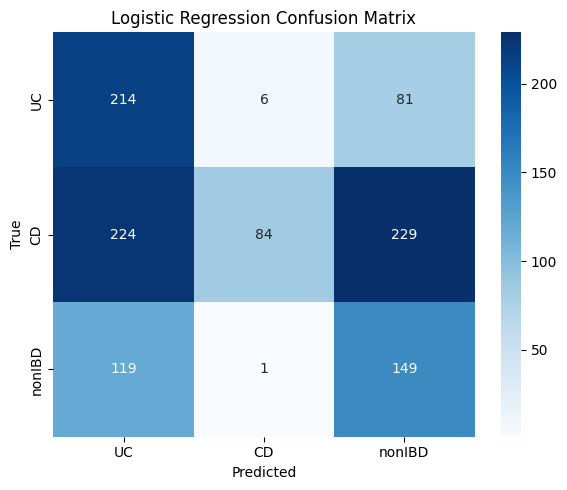

Top features by mean |coefficient| across classes:
cat__race_Black or African American           1.272197
cat__race_Other                               1.153076
cat__Arthralgia_Yes                           1.042936
cat__Arthralgia_No                            1.027832
cat__race_American Indian or Alaska Native    1.026392
cat__BMI_22.3                                 0.878363
cat__Anal fissure_Yes                         0.792032
cat__Abscess_Yes                              0.783254
cat__BMI_16.1                                 0.781004
cat__Anal fissure_No                          0.776928
cat__Abscess_No                               0.768150
cat__BMI_19.6                                 0.751701
cat__BMI_18.9                                 0.747878
cat__BMI_33.8                                 0.747878
cat__BMI_35.6                                 0.747878
cat__BMI_21.6                                 0.599100
cat__BMI_25.2                                 0.599100
cat__BMI_22.4 

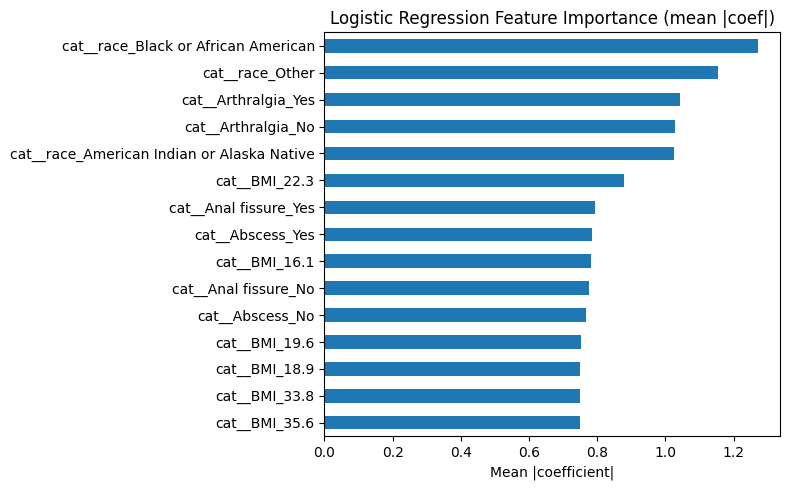

In [ ]:
# ===============================================
# PREPARE MODEL INPUT
# ===============================================

# extract data that is UC, CD, nonIBD
df_label = hmp_meta[hmp_meta['diagnosis'].isin(['UC', 'CD', 'nonIBD'])].copy()
print(df_label['diagnosis'].value_counts())
print(df_label['diagnosis'].value_counts(normalize=True) * 100)

# Start with few features
features = [
    'sex',
    'race',
    'Arthralgia',
    'Uveitis',
    'Erythema nodosum',
    'Pyoderma gangrenosum',
    'Anal fissure',
    'Abscess',
    'New fistula',
    'Partial Endoscopy',
    'BMI'
]

features = [c for c in features if c in df_label.columns]
print(features)


# Splitting the dataset
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeling table
model_df = df_label[features + ['diagnosis']].copy()
print(model_df.shape)
print(model_df.head())

# ===============================================
# IMPLEMENTATION
# ===============================================
# Simple model
X = model_df.drop(columns=['diagnosis'])
y = model_df['diagnosis'].map({'CD': 1, 'UC': 0, 'nonIBD': 2})

cat_cols = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

# =========================================================
# PLOT CONFUSION MATRIX
# =========================================================
cm_meta = confusion_matrix(y_test, pred)          # pred from clf.predict()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_meta, annot=True, fmt="d", cmap="Blues",   # consistent variable name
    xticklabels=["UC", "CD", "nonIBD"],            # matches your encoding:
    yticklabels=["UC", "CD", "nonIBD"]             # UC=0, CD=1, nonIBD=2
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")  # matches actual model used
plt.tight_layout()
plt.show()

# =========================================================
# FEATURE IMPORTANCE (Logistic Regression coefficients)
# =========================================================
# LogisticRegression has coef_, not feature_importances_
# For multiclass, coef_ shape is (n_classes, n_features)
lr_model      = clf.named_steps['model']          
encoder       = clf.named_steps['preprocess']
encoded_names = encoder.get_feature_names_out()    

# coef_ shape: (3 classes, n_features) — take mean absolute value across classes
importances = pd.Series(
    np.abs(lr_model.coef_).mean(axis=0),
    index=encoded_names
).sort_values(ascending=False)

print("Top features by mean |coefficient| across classes:")
print(importances.head(20).to_string())

# Plot
importances.head(15).plot(kind='barh', figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title("Logistic Regression Feature Importance (mean |coef|)")
plt.xlabel("Mean |coefficient|")
plt.tight_layout()
plt.show()

Result interpretation:

- The model is only moderately useful.
- Confusion matrix suggests the classifier is not capturing both UC and CD equally well.


## 2. Using metagenomics data (omics data) to predict diagnosis (UC, CD, nonIBD)
Download all metagenomics data from HMP2

In [4]:
# ===========================================
# Save MGX sample id into a text file
# ===========================================
sample_ids = [
"MSMAPC57_taxonomic_profile_3.tsv",
"CSM79HN6_taxonomic_profile_3.tsv",
"CSM5MCXD_taxonomic_profile_3.tsv",
"PSM6XBT1_taxonomic_profile_3.tsv",
"PSM7J15Q_taxonomic_profile_3.tsv",
"HSM7J4Q7_taxonomic_profile_3.tsv",
"HSM7J4J7_taxonomic_profile_3.tsv",
"PSM6XBTB_taxonomic_profile_3.tsv",
"HSM6XRQ8_taxonomic_profile_3.tsv",
"HSM7J4P2_taxonomic_profile_3.tsv",
"MSMAPC6M_taxonomic_profile_3.tsv",
"HSM7J4QZ_taxonomic_profile_3.tsv",
"PSM6XBTN_P_taxonomic_profile_3.tsv",
"MSM79H7W_taxonomic_profile_3.tsv",
"MSM6J2RK_taxonomic_profile_3.tsv",
"MSMA267V_taxonomic_profile_3.tsv",
"CSM7KOKF_taxonomic_profile_3.tsv",
"CSM9X1Z4_taxonomic_profile_3.tsv",
"MSM6J2PQ_P_taxonomic_profile_3.tsv",
"HSM5MD7J_taxonomic_profile_3.tsv",
"CSM79HOV_taxonomic_profile_3.tsv",
"HSM6XRR9_taxonomic_profile_3.tsv",
"MSM5LLD6_P_taxonomic_profile_3.tsv",
"PSM6XBVS_taxonomic_profile_3.tsv",
"MSMA26AZ_TR_taxonomic_profile_3.tsv",
"CSM67UF1_taxonomic_profile_3.tsv",
"HSMA33IO_taxonomic_profile_3.tsv",
"CSMAAEUA_taxonomic_profile_3.tsv",
"HSMA33LZ_taxonomic_profile_3.tsv",
"HSMA33LH_TR_taxonomic_profile_3.tsv",
"CSM79HLE_taxonomic_profile_3.tsv",
"CSMA88CB_taxonomic_profile_3.tsv",
"CSM7KOTU_taxonomic_profile_3.tsv",
"HSM7CYXS_taxonomic_profile_3.tsv",
"MSM79H9W_taxonomic_profile_3.tsv",
"CSM67U9H_P_taxonomic_profile_3.tsv",
"CSM67UE3_taxonomic_profile_3.tsv",
"HSM5FZBP_P_taxonomic_profile_3.tsv",
"MSMB4LZ4_taxonomic_profile_3.tsv",
"PSMA265N_taxonomic_profile_3.tsv",
"MSM9VZLL_taxonomic_profile_3.tsv",
"HSM67VGE_P_taxonomic_profile_3.tsv",
"PSM7J1BF_taxonomic_profile_3.tsv",
"HSMA33ME_taxonomic_profile_3.tsv",
"HSM7J4L5_taxonomic_profile_3.tsv",
"CSM67UDN_taxonomic_profile_3.tsv",
"PSM7J1C2_P_taxonomic_profile_3.tsv",
"MSM6J2RS_taxonomic_profile_3.tsv",
"CSM67U9T_P_taxonomic_profile_3.tsv",
"HSMA33LB_taxonomic_profile_3.tsv",
"HSMA33R5_taxonomic_profile_3.tsv",
"PSM7J1CS_P_taxonomic_profile_3.tsv",
"CSM5FZ3Z_P_taxonomic_profile_3.tsv",
"PSM7J18G_taxonomic_profile_3.tsv",
"MSM6J2LL_taxonomic_profile_3.tsv",
"MSM9VZIQ_taxonomic_profile_3.tsv",
"CSM9X21L_taxonomic_profile_3.tsv",
"CSM7KON8_taxonomic_profile_3.tsv",
"HSM7J4PM_taxonomic_profile_3.tsv",
"PSM7J1A2_taxonomic_profile_3.tsv",
"CSM9X237_taxonomic_profile_3.tsv",
"CSM67U9D_taxonomic_profile_3.tsv",
"PSM7J14X_taxonomic_profile_3.tsv",
"MSM6J2RM_taxonomic_profile_3.tsv",
"CSM79HJC_P_taxonomic_profile_3.tsv",
"MSMA26AR_taxonomic_profile_3.tsv",
"CSM79HRC_taxonomic_profile_3.tsv",
"HSM5MD6M_taxonomic_profile_3.tsv",
"HSMA33RD_taxonomic_profile_3.tsv",
"HSMA33PZ_taxonomic_profile_3.tsv",
"HSM67VEM_TR_taxonomic_profile_3.tsv",
"MSM79H5A_taxonomic_profile_3.tsv",
"HSM7J4OP_taxonomic_profile_3.tsv",
"MSM6J2RA_taxonomic_profile_3.tsv",
"HSM7J4GP_taxonomic_profile_3.tsv",
"CSM67UAM_taxonomic_profile_3.tsv",
"MSMA267X_taxonomic_profile_3.tsv",
"MSM9VZGS_taxonomic_profile_3.tsv",
"MSM5LLGN_P_taxonomic_profile_3.tsv",
"HSM7J4N4_taxonomic_profile_3.tsv",
"PSMA269S_taxonomic_profile_3.tsv",
"MSM9VZHZ_taxonomic_profile_3.tsv",
"CSM7KOS7_taxonomic_profile_3.tsv",
"CSM67U9V_P_taxonomic_profile_3.tsv",
"MSM9VZLV_taxonomic_profile_3.tsv",
"CSM9X21N_taxonomic_profile_3.tsv",
"MSM9VZOU_taxonomic_profile_3.tsv",
"HSM7CYX6_taxonomic_profile_3.tsv",
"CSM67UBN_taxonomic_profile_3.tsv",
"HSM5MD71_taxonomic_profile_3.tsv",
"HSM67VDT_taxonomic_profile_3.tsv",
"HSM6XRTQ_taxonomic_profile_3.tsv",
"MSM9VZOK_taxonomic_profile_3.tsv",
"CSM7KOOF_taxonomic_profile_3.tsv",
"HSM6XRUN_taxonomic_profile_3.tsv",
"PSM7J15O_taxonomic_profile_3.tsv",
"HSM7J4M8_taxonomic_profile_3.tsv",
"MSM6J2JH_P_taxonomic_profile_3.tsv",
"MSM9VZN4_P_taxonomic_profile_3.tsv",
"MSM79H6B_taxonomic_profile_3.tsv",
"PSM7J1CC_taxonomic_profile_3.tsv",
"MSM6J2OH_taxonomic_profile_3.tsv",
"ESM5GEYY_P_taxonomic_profile_3.tsv",
"HSM6XRVU_taxonomic_profile_3.tsv",
"MSM79H8B_taxonomic_profile_3.tsv",
"MSM79HDS_taxonomic_profile_3.tsv",
"CSM79HPO_taxonomic_profile_3.tsv",
"MSM9VZJJ_P_taxonomic_profile_3.tsv",
"CSM7KOSL_taxonomic_profile_3.tsv",
"MSM79HCR_taxonomic_profile_3.tsv",
"HSMA33SK_taxonomic_profile_3.tsv",
"HSM7J4PG_taxonomic_profile_3.tsv",
"PSM7J19Z_taxonomic_profile_3.tsv",
"HSM7CZ1T_P_taxonomic_profile_3.tsv",
"HSM7CZ2J_P_taxonomic_profile_3.tsv",
"HSM7J4HO_taxonomic_profile_3.tsv",
"PSM6XBV2_taxonomic_profile_3.tsv",
"CSM7KONK_taxonomic_profile_3.tsv",
"HSM5MD87_P_taxonomic_profile_3.tsv",
"CSM7KOLY_taxonomic_profile_3.tsv",
"CSM7KONU_taxonomic_profile_3.tsv",
"HSM5MEE5_P_taxonomic_profile_3.tsv",
"HSM7CZ3G_taxonomic_profile_3.tsv",
"MSM6J2Q3_taxonomic_profile_3.tsv",
"HSM67VGA_taxonomic_profile_3.tsv",
"CSM7KOKP_P_taxonomic_profile_3.tsv",
"HSM67VDT_P_taxonomic_profile_3.tsv",
"CSM5FZ3X_P_taxonomic_profile_3.tsv",
"HSM5MD75_taxonomic_profile_3.tsv",
"MSM79H9G_taxonomic_profile_3.tsv",
"MSMA26BD_taxonomic_profile_3.tsv",
"PSMA263W_taxonomic_profile_3.tsv",
"HSM7CZ3E_taxonomic_profile_3.tsv",
"MSM79H67_taxonomic_profile_3.tsv",
"CSM67UAI_P_taxonomic_profile_3.tsv",
"CSM5MCV1_P_taxonomic_profile_3.tsv",
"HSM7CZ22_taxonomic_profile_3.tsv",
"MSM5LLFO_P_taxonomic_profile_3.tsv",
"MSMB4LZV_taxonomic_profile_3.tsv",
"CSM7KOOR_taxonomic_profile_3.tsv",
"MSM79H6F_taxonomic_profile_3.tsv",
"HSM67VH1_taxonomic_profile_3.tsv",
"CSM79HQF_taxonomic_profile_3.tsv",
"MSM6J2JT_taxonomic_profile_3.tsv",
"PSMB4MC1_taxonomic_profile_3.tsv",
"HSMA33J9_taxonomic_profile_3.tsv",
"HSMA33OP_taxonomic_profile_3.tsv",
"HSM7J4LD_taxonomic_profile_3.tsv",
"PSM7J1BB_taxonomic_profile_3.tsv",
"PSM7J16W_taxonomic_profile_3.tsv",
"HSM7CYY9_taxonomic_profile_3.tsv",
"MSM6J2RQ_taxonomic_profile_3.tsv",
"CSM9X1YV_taxonomic_profile_3.tsv",
"PSM7J184_taxonomic_profile_3.tsv",
"ESM5MEB7_taxonomic_profile_3.tsv",
"HSM6XRVK_taxonomic_profile_3.tsv",
"MSM5LLIK_P_taxonomic_profile_3.tsv",
"HSM67VDR_P_taxonomic_profile_3.tsv",
"CSM67UB9_taxonomic_profile_3.tsv",
"HSM7J4KK_taxonomic_profile_3.tsv",
"HSM7J4NS_taxonomic_profile_3.tsv",
"MSM6J2IG_taxonomic_profile_3.tsv",
"PSM7J1B7_taxonomic_profile_3.tsv",
"CSM79HNM_taxonomic_profile_3.tsv",
"PSM7J12Z_taxonomic_profile_3.tsv",
"CSM7KOPE_taxonomic_profile_3.tsv",
"CSM79HGJ_P_taxonomic_profile_3.tsv",
"MSMA26EJ_taxonomic_profile_3.tsv",
"CSMAG78W_taxonomic_profile_3.tsv",
"MSM6J2LW_taxonomic_profile_3.tsv",
"HSM67VG6_P_taxonomic_profile_3.tsv",
"CSM79HLM_taxonomic_profile_3.tsv",
"MSM6J2R8_taxonomic_profile_3.tsv",
"HSM5MD4N_taxonomic_profile_3.tsv",
"PSM6XBQS_taxonomic_profile_3.tsv",
"HSM7J4HW_taxonomic_profile_3.tsv",
"CSM7KOQP_P_taxonomic_profile_3.tsv",
"HSM7J4KC_taxonomic_profile_3.tsv",
"MSM9VZOI_taxonomic_profile_3.tsv",
"CSM67UBX_taxonomic_profile_3.tsv",
"PSMA265L_taxonomic_profile_3.tsv",
"CSM7KOKZ_taxonomic_profile_3.tsv",
"MSM6J2LT_taxonomic_profile_3.tsv",
"MSMA26AX_taxonomic_profile_3.tsv",
"HSM5MD5P_taxonomic_profile_3.tsv",
"HSM7J4PE_taxonomic_profile_3.tsv",
"MSM79H94_P_taxonomic_profile_3.tsv",
"HSM5MD8L_P_taxonomic_profile_3.tsv",
"MSM9VZHP_taxonomic_profile_3.tsv",
"CSM7KOSP_taxonomic_profile_3.tsv",
"CSM79HJ8_P_taxonomic_profile_3.tsv",
"MSMB4LYH_taxonomic_profile_3.tsv",
"MSM5LLGL_taxonomic_profile_3.tsv",
"MSM79HFB_taxonomic_profile_3.tsv",
"HSM7CYXC_taxonomic_profile_3.tsv",
"MSM79H63_taxonomic_profile_3.tsv",
"CSM5MCWC_taxonomic_profile_3.tsv",
"CSM79HKB_taxonomic_profile_3.tsv",
"CSM5MCUS_P_taxonomic_profile_3.tsv",
"MSM5LLH8_P_taxonomic_profile_3.tsv",
"MSMA26BV_taxonomic_profile_3.tsv",
"HSM7J4OE_taxonomic_profile_3.tsv",
"MSM5LLDK_taxonomic_profile_3.tsv",
"HSMA33MK_taxonomic_profile_3.tsv",
"CSM5MCXP_taxonomic_profile_3.tsv",
"CSM79HJ2_P_taxonomic_profile_3.tsv",
"HSM6XRQS_taxonomic_profile_3.tsv",
"HSM7J4PW_taxonomic_profile_3.tsv",
"HSM5MD6C_taxonomic_profile_3.tsv",
"PSM7J193_taxonomic_profile_3.tsv",
"HSM67VIL_taxonomic_profile_3.tsv",
"MSM9VZGO_taxonomic_profile_3.tsv",
"HSMA33J1_P_taxonomic_profile_3.tsv",
"HSM7J4IR_taxonomic_profile_3.tsv",
"MSM79HFY_taxonomic_profile_3.tsv",
"CSM79HR4_taxonomic_profile_3.tsv",
"MSMA26BB_taxonomic_profile_3.tsv",
"ESM5MEEJ_P_taxonomic_profile_3.tsv",
"CSM5MCUO_taxonomic_profile_3.tsv",
"HSM5MD7Z_P_taxonomic_profile_3.tsv",
"PSMA265J_taxonomic_profile_3.tsv",
"HSM5MD53_taxonomic_profile_3.tsv",
"CSM67UBH_taxonomic_profile_3.tsv",
"HSM6XRTC_P_taxonomic_profile_3.tsv",
"MSM9VZHB_taxonomic_profile_3.tsv",
"CSM5MCXF_P_taxonomic_profile_3.tsv",
"ESM718SY_taxonomic_profile_3.tsv",
"HSM7CYZJ_taxonomic_profile_3.tsv",
"HSM67VFR_taxonomic_profile_3.tsv",
"HSM67VHS_taxonomic_profile_3.tsv",
"CSM79HQ9_taxonomic_profile_3.tsv",
"HSMA33S4_taxonomic_profile_3.tsv",
"MSM6J2HL_taxonomic_profile_3.tsv",
"HSM7J4O7_taxonomic_profile_3.tsv",
"MSM79H8D_taxonomic_profile_3.tsv",
"MSM79HAJ_taxonomic_profile_3.tsv",
"HSM7J4HK_taxonomic_profile_3.tsv",
"HSM7J4Q1_taxonomic_profile_3.tsv",
"CSM79HQV_taxonomic_profile_3.tsv",
"MSM7J16J_taxonomic_profile_3.tsv",
"MSM79H5Y_taxonomic_profile_3.tsv",
"PSM7J19F_taxonomic_profile_3.tsv",
"HSM7CZ2V_P_taxonomic_profile_3.tsv",
"MSM9VZIY_taxonomic_profile_3.tsv",
"CSM67U9J_taxonomic_profile_3.tsv",
"PSMA267F_taxonomic_profile_3.tsv",
"HSM67VDX_P_taxonomic_profile_3.tsv",
"CSM67U9N_taxonomic_profile_3.tsv",
"HSMA33R1_taxonomic_profile_3.tsv",
"CSM5FZ4A_P_taxonomic_profile_3.tsv",
"PSM7J19H_taxonomic_profile_3.tsv",
"HSM6XRTG_P_taxonomic_profile_3.tsv",
"MSM6J2IO_taxonomic_profile_3.tsv",
"CSM9X1ZY_taxonomic_profile_3.tsv",
"MSM79H9U_P_taxonomic_profile_3.tsv",
"MSM9VZMS_taxonomic_profile_3.tsv",
"MSM5LLGD_P_taxonomic_profile_3.tsv",
"CSM79HGN_P_taxonomic_profile_3.tsv",
"CSMA9J65_taxonomic_profile_3.tsv",
"MSM5LLF2_P_taxonomic_profile_3.tsv",
"ESM5ME9H_P_taxonomic_profile_3.tsv",
"HSM5FZC2_P_taxonomic_profile_3.tsv",
"CSM79HJW_taxonomic_profile_3.tsv",
"PSM6XBSC_P_taxonomic_profile_3.tsv",
"CSM79HNY_P_taxonomic_profile_3.tsv",
"CSM5MCVF_P_taxonomic_profile_3.tsv",
"CSM79HIT_taxonomic_profile_3.tsv",
"CSM67UAS_taxonomic_profile_3.tsv",
"HSM7J4L9_taxonomic_profile_3.tsv",
"ESM5MEE2_P_taxonomic_profile_3.tsv",
"MSM5LLFG_P_taxonomic_profile_3.tsv",
"HSM5MD6Q_taxonomic_profile_3.tsv",
"PSM6XBRK_taxonomic_profile_3.tsv",
"HSM6XRR7_taxonomic_profile_3.tsv",
"HSM7CZ1V_taxonomic_profile_3.tsv",
"MSM6J2IQ_taxonomic_profile_3.tsv",
"MSM5LLIG_P_taxonomic_profile_3.tsv",
"HSM5MD8J_P_taxonomic_profile_3.tsv",
"HSM5MD66_taxonomic_profile_3.tsv",
"CSM7KOSJ_taxonomic_profile_3.tsv",
"MSM9VZOW_taxonomic_profile_3.tsv",
"HSM7J4GD_taxonomic_profile_3.tsv",
"PSM7J1BX_taxonomic_profile_3.tsv",
"MSM9VZEM_taxonomic_profile_3.tsv",
"CSM7KOL2_taxonomic_profile_3.tsv",
"ESM5MEC7_P_taxonomic_profile_3.tsv",
"MSM9VZHJ_taxonomic_profile_3.tsv",
"MSM6J2JZ_taxonomic_profile_3.tsv",
"HSM6XRQY_taxonomic_profile_3.tsv",
"MSM9VZEK_taxonomic_profile_3.tsv",
"MSM6J2QD_taxonomic_profile_3.tsv",
"ESM5MEBI_taxonomic_profile_3.tsv",
"CSM79HGH_P_taxonomic_profile_3.tsv",
"HSM7J4MC_taxonomic_profile_3.tsv",
"PSMB4MC3_taxonomic_profile_3.tsv",
"PSM6XBTR_taxonomic_profile_3.tsv",
"PSM7J15S_taxonomic_profile_3.tsv",
"HSM6XRSX_P_taxonomic_profile_3.tsv",
"MSMA26BL_taxonomic_profile_3.tsv",
"PSM7J13Y_P_taxonomic_profile_3.tsv",
"PSM6XBS4_P_taxonomic_profile_3.tsv",
"PSMA266Y_taxonomic_profile_3.tsv",
"MSM6J2Q7_taxonomic_profile_3.tsv",
"CSM7KOUN_taxonomic_profile_3.tsv",
"PSM7J177_taxonomic_profile_3.tsv",
"PSM6XBU2_taxonomic_profile_3.tsv",
"HSMA33KO_taxonomic_profile_3.tsv",
"MSM6J2R2_taxonomic_profile_3.tsv",
"HSM6XRUV_taxonomic_profile_3.tsv",
"CSM79HI7_taxonomic_profile_3.tsv",
"HSM5MD6O_P_taxonomic_profile_3.tsv",
"MSM6J2HR_taxonomic_profile_3.tsv",
"HSM7CYZV_taxonomic_profile_3.tsv",
"PSM6XBUG_taxonomic_profile_3.tsv",
"MSM9VZEY_taxonomic_profile_3.tsv",
"HSM7CYXI_taxonomic_profile_3.tsv",
"PSM7J19R_taxonomic_profile_3.tsv",
"PSM7J12V_taxonomic_profile_3.tsv",
"HSM67VCX_P_taxonomic_profile_3.tsv",
"CSM79HIR_taxonomic_profile_3.tsv",
"HSMA33P2_P_taxonomic_profile_3.tsv",
"CSM79HRG_taxonomic_profile_3.tsv",
"PSMA2659_taxonomic_profile_3.tsv",
"MSM79H5Q_taxonomic_profile_3.tsv",
"MSM79H8J_P_taxonomic_profile_3.tsv",
"CSM7KOPO_taxonomic_profile_3.tsv",
"PSM7J17F_taxonomic_profile_3.tsv",
"HSMA33IC_taxonomic_profile_3.tsv",
"MSM9VZFJ_P_taxonomic_profile_3.tsv",
"MSM6J2JP_taxonomic_profile_3.tsv",
"HSMA33OD_taxonomic_profile_3.tsv",
"MSM9VZMI_taxonomic_profile_3.tsv",
"HSM6XRSX_taxonomic_profile_3.tsv",
"HSM7J4JZ_taxonomic_profile_3.tsv",
"HSMA33JR_taxonomic_profile_3.tsv",
"HSM7J4RE_taxonomic_profile_3.tsv",
"HSM7J4QT_taxonomic_profile_3.tsv",
"HSM7J4NU_taxonomic_profile_3.tsv",
"MSM9VZMU_taxonomic_profile_3.tsv",
"HSM7CYXQ_taxonomic_profile_3.tsv",
"HSM5MD6I_taxonomic_profile_3.tsv",
"MSM5FZ9X_P_taxonomic_profile_3.tsv",
"MSM79H6L_taxonomic_profile_3.tsv",
"PSM6XBR1_taxonomic_profile_3.tsv",
"HSMA33RX_taxonomic_profile_3.tsv",
"MSM5LLHX_P_taxonomic_profile_3.tsv",
"MSMA26EZ_taxonomic_profile_3.tsv",
"CSM5MCX3_taxonomic_profile_3.tsv",
"CSM67UAY_taxonomic_profile_3.tsv",
"HSM7J4MW_taxonomic_profile_3.tsv",
"MSM9VZHL_taxonomic_profile_3.tsv",
"CSM79HNU_taxonomic_profile_3.tsv",
"CSM79HOT_taxonomic_profile_3.tsv",
"MSM79HDQ_taxonomic_profile_3.tsv",
"MSMA2688_taxonomic_profile_3.tsv",
"MSM5LLDC_taxonomic_profile_3.tsv",
"PSM6XBSM_taxonomic_profile_3.tsv",
"PSM6XBS4_taxonomic_profile_3.tsv",
"MSMA26AP_taxonomic_profile_3.tsv",
"PSM7J1BV_taxonomic_profile_3.tsv",
"MSM79H98_taxonomic_profile_3.tsv",
"CSM7KOPK_taxonomic_profile_3.tsv",
"HSM7CZ1G_taxonomic_profile_3.tsv",
"MSM79H5E_taxonomic_profile_3.tsv",
"PSM6XBUK_taxonomic_profile_3.tsv",
"CSM7KOOV_taxonomic_profile_3.tsv",
"CSM79HIX_taxonomic_profile_3.tsv",
"MSM79H6N_taxonomic_profile_3.tsv",
"HSM6XRTG_taxonomic_profile_3.tsv",
"MSM6J2QH_taxonomic_profile_3.tsv",
"CSM79HK9_taxonomic_profile_3.tsv",
"HSMA33MS_taxonomic_profile_3.tsv",
"CSM7KOU7_P_taxonomic_profile_3.tsv",
"PSM7J1BL_taxonomic_profile_3.tsv",
"HSM67VID_taxonomic_profile_3.tsv",
"MSMAPC7T_taxonomic_profile_3.tsv",
"MSMA26ER_taxonomic_profile_3.tsv",
"CSM5MCWQ_taxonomic_profile_3.tsv",
"MSM9VZLX_P_taxonomic_profile_3.tsv",
"HSMA33PN_taxonomic_profile_3.tsv",
"PSM7J13I_taxonomic_profile_3.tsv",
"PSM7J173_taxonomic_profile_3.tsv",
"MSM6J2IK_taxonomic_profile_3.tsv",
"HSM6XRS4_taxonomic_profile_3.tsv",
"PSMA267R_taxonomic_profile_3.tsv",
"HSM7J4QD_taxonomic_profile_3.tsv",
"HSM67VI9_taxonomic_profile_3.tsv",
"HSM5MD6S_P_taxonomic_profile_3.tsv",
"MSMA26ET_taxonomic_profile_3.tsv",
"CSM79HPM_P_taxonomic_profile_3.tsv",
"CSM79HH4_taxonomic_profile_3.tsv",
"HSM67VG2_P_taxonomic_profile_3.tsv",
"ESM5MECQ_taxonomic_profile_3.tsv",
"HSM67VEK_taxonomic_profile_3.tsv",
"MSM79H8F_taxonomic_profile_3.tsv",
"MSM6J2IE_taxonomic_profile_3.tsv",
"ESM5MEBE_taxonomic_profile_3.tsv",
"HSM67VD6_taxonomic_profile_3.tsv",
"HSM5MD4U_P_taxonomic_profile_3.tsv",
"HSMA33J5_taxonomic_profile_3.tsv",
"CSM5MCXH_taxonomic_profile_3.tsv",
"ESM7F5CD_taxonomic_profile_3.tsv",
"CSM7KOUJ_P_taxonomic_profile_3.tsv",
"HSM67VFH_taxonomic_profile_3.tsv",
"MSM5LLF8_taxonomic_profile_3.tsv",
"CSM7KOTC_taxonomic_profile_3.tsv",
"HSM5MD3Y_taxonomic_profile_3.tsv",
"MSM5LLIQ_P_taxonomic_profile_3.tsv",
"CSM5MCVZ_P_taxonomic_profile_3.tsv",
"CSM5FZ42_P_taxonomic_profile_3.tsv",
"HSM67VEW_taxonomic_profile_3.tsv",
"CSM9X1ZC_taxonomic_profile_3.tsv",
"PSM7J19J_taxonomic_profile_3.tsv",
"MSM79H81_taxonomic_profile_3.tsv",
"CSM79HID_taxonomic_profile_3.tsv",
"CSM9X1ZQ_taxonomic_profile_3.tsv",
"HSM7J4HS_taxonomic_profile_3.tsv",
"HSM67VHK_taxonomic_profile_3.tsv",
"CSM79HJS_taxonomic_profile_3.tsv",
"HSM67VFJ_taxonomic_profile_3.tsv",
"HSM5MD57_P_taxonomic_profile_3.tsv",
"MSM5LLER_taxonomic_profile_3.tsv",
"MSM9VZMM_taxonomic_profile_3.tsv",
"CSM7KOMR_P_taxonomic_profile_3.tsv",
"PSM6XBTL_taxonomic_profile_3.tsv",
"HSMA33JP_taxonomic_profile_3.tsv",
"HSM5MD5B_P_taxonomic_profile_3.tsv",
"MSM79HDK_taxonomic_profile_3.tsv",
"HSM6XRQI_taxonomic_profile_3.tsv",
"CSM5MCUY_P_taxonomic_profile_3.tsv",
"MSMAPC6E_taxonomic_profile_3.tsv",
"CSM5MCUQ_P_taxonomic_profile_3.tsv",
"MSMA26EL_taxonomic_profile_3.tsv",
"CSM5MCZD_taxonomic_profile_3.tsv",
"CSM7KOR4_P_taxonomic_profile_3.tsv",
"CSM67UET_P_taxonomic_profile_3.tsv",
"CSM67UFZ_taxonomic_profile_3.tsv",
"MSM6J2MJ_taxonomic_profile_3.tsv",
"CSMACTZP_taxonomic_profile_3.tsv",
"MSM6J2K4_taxonomic_profile_3.tsv",
"MSMAPC5H_taxonomic_profile_3.tsv",
"CSM7KOJQ_taxonomic_profile_3.tsv",
"ESM5MEAB_P_taxonomic_profile_3.tsv",
"MSM6J2RG_P_taxonomic_profile_3.tsv",
"HSM7J4PK_taxonomic_profile_3.tsv",
"MSM6J2JN_taxonomic_profile_3.tsv",
"ESM718TK_taxonomic_profile_3.tsv",
"HSM67VI7_taxonomic_profile_3.tsv",
"HSM6XRT8_taxonomic_profile_3.tsv",
"CSM67UAO_taxonomic_profile_3.tsv",
"HSM7J4HY_taxonomic_profile_3.tsv",
"CSM7KOJY_taxonomic_profile_3.tsv",
"MSM9VZOO_taxonomic_profile_3.tsv",
"PSM6XBTD_taxonomic_profile_3.tsv",
"CSM67UB3_taxonomic_profile_3.tsv",
"PSM7J156_taxonomic_profile_3.tsv",
"HSM7J4PU_taxonomic_profile_3.tsv",
"CSM79HGF_taxonomic_profile_3.tsv",
"MSM79H52_P_taxonomic_profile_3.tsv",
"MSM79HDU_taxonomic_profile_3.tsv",
"HSM67VHJ_taxonomic_profile_3.tsv",
"MSM79HF7_taxonomic_profile_3.tsv",
"HSM6XRQB_taxonomic_profile_3.tsv",
"PSMA2651_P_taxonomic_profile_3.tsv",
"MSM79HEW_taxonomic_profile_3.tsv",
"HSM6XRQE_P_taxonomic_profile_3.tsv",
"HSM5MD6A_TR_taxonomic_profile_3.tsv",
"HSMA33L1_taxonomic_profile_3.tsv",
"CSM79HJQ_taxonomic_profile_3.tsv",
"PSM6XBUO_taxonomic_profile_3.tsv",
"PSMB4MBI_taxonomic_profile_3.tsv",
"HSM7J4IS_taxonomic_profile_3.tsv",
"MSM79HB6_taxonomic_profile_3.tsv",
"MSMA26DO_taxonomic_profile_3.tsv",
"HSM7J4PO_taxonomic_profile_3.tsv",
"MSM9VZHF_taxonomic_profile_3.tsv",
"HSMA33NQ_taxonomic_profile_3.tsv",
"CSM5MCVJ_P_taxonomic_profile_3.tsv",
"CSM7KOUB_taxonomic_profile_3.tsv",
"CSM67UB5_P_taxonomic_profile_3.tsv",
"PSM7J19X_P_taxonomic_profile_3.tsv",
"MSMA26DM_taxonomic_profile_3.tsv",
"MSM5LLEP_taxonomic_profile_3.tsv",
"CSM67U9X_P_taxonomic_profile_3.tsv",
"MSM6J2PM_taxonomic_profile_3.tsv",
"CSM67UDR_taxonomic_profile_3.tsv",
"MSM6J2QJ_taxonomic_profile_3.tsv",
"HSM7J4O1_taxonomic_profile_3.tsv",
"MSM9VZO2_taxonomic_profile_3.tsv",
"MSM6J2QB_taxonomic_profile_3.tsv",
"HSM67VIJ_P_taxonomic_profile_3.tsv",
"PSMA265D_taxonomic_profile_3.tsv",
"CSM5FZ4K_P_taxonomic_profile_3.tsv",
"MSM9VZHN_taxonomic_profile_3.tsv",
"MSM79HA7_taxonomic_profile_3.tsv",
"MSMA26DK_taxonomic_profile_3.tsv",
"HSMA33R9_taxonomic_profile_3.tsv",
"MSM5LLGR_P_taxonomic_profile_3.tsv",
"HSM7CYY7_taxonomic_profile_3.tsv",
"PSM7J17Z_taxonomic_profile_3.tsv",
"MSM9VZI6_taxonomic_profile_3.tsv",
"CSM7KOOL_taxonomic_profile_3.tsv",
"CSM79HP2_taxonomic_profile_3.tsv",
"CSM79HOZ_taxonomic_profile_3.tsv",
"CSM79HNW_taxonomic_profile_3.tsv",
"CSM5MCXN_taxonomic_profile_3.tsv",
"CSM67UA2_taxonomic_profile_3.tsv",
"MSM6J2HJ_taxonomic_profile_3.tsv",
"MSMB4LZZ_taxonomic_profile_3.tsv",
"MSM9VZHT_taxonomic_profile_3.tsv",
"CSM7CZ2F_P_taxonomic_profile_3.tsv",
"HSMA33MG_taxonomic_profile_3.tsv",
"CSM5MCXL_taxonomic_profile_3.tsv",
"MSM5LLDS_taxonomic_profile_3.tsv",
"CSM7KOQX_taxonomic_profile_3.tsv",
"PSM7J17T_taxonomic_profile_3.tsv",
"HSM7J4I7_taxonomic_profile_3.tsv",
"MSM9VZKE_taxonomic_profile_3.tsv",
"PSMA264O_taxonomic_profile_3.tsv",
"CSM67UCK_taxonomic_profile_3.tsv",
"HSM5MD8A_P_taxonomic_profile_3.tsv",
"CSM79HJM_taxonomic_profile_3.tsv",
"ESM7F5C7_taxonomic_profile_3.tsv",
"PSM7J17D_taxonomic_profile_3.tsv",
"HSM7J4KA_taxonomic_profile_3.tsv",
"MSMAPC5D_taxonomic_profile_3.tsv",
"CSMAE44D_taxonomic_profile_3.tsv",
"CSM79HLG_taxonomic_profile_3.tsv",
"HSM7J4K8_taxonomic_profile_3.tsv",
"MSM79H58_taxonomic_profile_3.tsv",
"HSM7J4HM_taxonomic_profile_3.tsv",
"CSM7KOL4_taxonomic_profile_3.tsv",
"CSM9X22S_taxonomic_profile_3.tsv",
"HSM7CYZB_taxonomic_profile_3.tsv",
"MSM6J2LV_taxonomic_profile_3.tsv",
"CSM7KOPI_taxonomic_profile_3.tsv",
"MSM6J2PO_taxonomic_profile_3.tsv",
"PSM7J1BP_taxonomic_profile_3.tsv",
"PSM6XBT3_taxonomic_profile_3.tsv",
"HSM67VD4_taxonomic_profile_3.tsv",
"HSM5MD5B_taxonomic_profile_3.tsv",
"HSM67VGK_TR_taxonomic_profile_3.tsv",
"CSM79HMP_taxonomic_profile_3.tsv",
"HSMA33QO_taxonomic_profile_3.tsv",
"HSM67VI3_taxonomic_profile_3.tsv",
"CSM67UF5_taxonomic_profile_3.tsv",
"HSM6XRRB_taxonomic_profile_3.tsv",
"CSM5LLGB_P_taxonomic_profile_3.tsv",
"HSM5MD7Q_taxonomic_profile_3.tsv",
"MSM5LLIC_P_taxonomic_profile_3.tsv",
"MSM5LLI6_P_taxonomic_profile_3.tsv",
"PSMA266O_taxonomic_profile_3.tsv",
"MSM6J2JB_taxonomic_profile_3.tsv",
"CSM7KOKD_taxonomic_profile_3.tsv",
"HSM5MD8B_P_taxonomic_profile_3.tsv",
"HSM7J4IU_taxonomic_profile_3.tsv",
"MSM5LLI8_P_taxonomic_profile_3.tsv",
"PSM7J18I_taxonomic_profile_3.tsv",
"HSMA33NG_P_taxonomic_profile_3.tsv",
"MSM9VZMA_TR_taxonomic_profile_3.tsv",
"CSM7KOKB_taxonomic_profile_3.tsv",
"CSM5MCYW_taxonomic_profile_3.tsv",
"HSM7CYYH_taxonomic_profile_3.tsv",
"MSM79HD6_P_taxonomic_profile_3.tsv",
"MSMAPC6A_taxonomic_profile_3.tsv",
"HSM7J4M4_taxonomic_profile_3.tsv",
"MSM9VZMA_taxonomic_profile_3.tsv",
"HSM67VGA_P_taxonomic_profile_3.tsv",
"MSM79HBZ_taxonomic_profile_3.tsv",
"MSMB4LZC_taxonomic_profile_3.tsv",
"HSMA33KE_taxonomic_profile_3.tsv",
"MSM6J2MH_taxonomic_profile_3.tsv",
"HSMA33JZ_taxonomic_profile_3.tsv",
"MSM9VZL5_taxonomic_profile_3.tsv",
"CSM5MCXZ_P_taxonomic_profile_3.tsv",
"HSM6XRVW_taxonomic_profile_3.tsv",
"CSM5MCUW_P_taxonomic_profile_3.tsv",
"HSM7CYY5_taxonomic_profile_3.tsv",
"HSM5MD5X_P_taxonomic_profile_3.tsv",
"HSM7CYYV_P_taxonomic_profile_3.tsv",
"HSMA33OL_taxonomic_profile_3.tsv",
"HSM5MD7U_taxonomic_profile_3.tsv",
"MSMAPC6K_taxonomic_profile_3.tsv",
"MSM5LLGJ_P_taxonomic_profile_3.tsv",
"CSM7KOTO_taxonomic_profile_3.tsv",
"HSMA33KM_taxonomic_profile_3.tsv",
"CSM67UAG_taxonomic_profile_3.tsv",
"ESM7F5C5_taxonomic_profile_3.tsv",
"HSM7J4QB_taxonomic_profile_3.tsv",
"CSM7KOK3_taxonomic_profile_3.tsv",
"MSM5LLF4_taxonomic_profile_3.tsv",
"PSM7J14N_taxonomic_profile_3.tsv",
"ESM5MED2_taxonomic_profile_3.tsv",
"CSM79HGX_taxonomic_profile_3.tsv",
"HSM7J4I9_taxonomic_profile_3.tsv",
"MSM6J2KC_taxonomic_profile_3.tsv",
"MSM9VZP3_taxonomic_profile_3.tsv",
"PSM7J129_taxonomic_profile_3.tsv",
"CSM79HN2_taxonomic_profile_3.tsv",
"CSM7KOOX_taxonomic_profile_3.tsv",
"HSM6XRUL_taxonomic_profile_3.tsv",
"CSM7KOMT_taxonomic_profile_3.tsv",
"MSM9VZPN_taxonomic_profile_3.tsv",
"HSM7CZ2A_taxonomic_profile_3.tsv",
"HSM67VIB_taxonomic_profile_3.tsv",
"PSM7J12D_taxonomic_profile_3.tsv",
"HSM5MD82_P_taxonomic_profile_3.tsv",
"HSMA33R7_taxonomic_profile_3.tsv",
"MSM79HA1_taxonomic_profile_3.tsv",
"CSM79HR2_taxonomic_profile_3.tsv",
"MSM9VZLH_taxonomic_profile_3.tsv",
"PSM7J1BJ_taxonomic_profile_3.tsv",
"MSMA26AN_taxonomic_profile_3.tsv",
"HSMA33KS_taxonomic_profile_3.tsv",
"MSM7J16L_taxonomic_profile_3.tsv",
"ESM5GEZ3_P_taxonomic_profile_3.tsv",
"HSM7J4KG_taxonomic_profile_3.tsv",
"HSM7J4MY_taxonomic_profile_3.tsv",
"PSM7J1CU_taxonomic_profile_3.tsv",
"PSM7J163_taxonomic_profile_3.tsv",
"HSM7CYXE_taxonomic_profile_3.tsv",
"PSM7J1AW_taxonomic_profile_3.tsv",
"MSM79HDC_taxonomic_profile_3.tsv",
"HSM6XRVC_taxonomic_profile_3.tsv",
"CSM79HH8_taxonomic_profile_3.tsv",
"CSM79HPA_TR_taxonomic_profile_3.tsv",
"MSMA26AT_taxonomic_profile_3.tsv",
"HSMA33IK_taxonomic_profile_3.tsv",
"CSM7KOOP_taxonomic_profile_3.tsv",
"PSMB4MC5_taxonomic_profile_3.tsv",
"CSM67UBB_taxonomic_profile_3.tsv",
"PSM6XBVM_taxonomic_profile_3.tsv",
"MSM6J2QL_taxonomic_profile_3.tsv",
"HSM7CZ32_taxonomic_profile_3.tsv",
"MSM5LLIE_P_taxonomic_profile_3.tsv",
"HSM7J4JN_taxonomic_profile_3.tsv",
"MSM79HBV_taxonomic_profile_3.tsv",
"MSM5LLDE_taxonomic_profile_3.tsv",
"HSM6XRV8_taxonomic_profile_3.tsv",
"HSM6XRTO_taxonomic_profile_3.tsv",
"CSM7KORK_taxonomic_profile_3.tsv",
"CSM9X21R_taxonomic_profile_3.tsv",
"PSM7J18K_taxonomic_profile_3.tsv",
"MSM9VZEK_TR_taxonomic_profile_3.tsv",
"CSM5MCYI_P_taxonomic_profile_3.tsv",
"PSM7J1C4_taxonomic_profile_3.tsv",
"HSM7CZ3C_taxonomic_profile_3.tsv",
"HSMA33N4_taxonomic_profile_3.tsv",
"PSM7J1BH_taxonomic_profile_3.tsv",
"MSM6J2SK_taxonomic_profile_3.tsv",
"HSM6XRS8_taxonomic_profile_3.tsv",
"HSM7J4MK_taxonomic_profile_3.tsv",
"CSM7KOLM_taxonomic_profile_3.tsv",
"HSM5MD47_P_taxonomic_profile_3.tsv",
"CSM79HOF_taxonomic_profile_3.tsv",
"PSM7J4EF_taxonomic_profile_3.tsv",
"MSM6J2K2_taxonomic_profile_3.tsv",
"CSM9X219_taxonomic_profile_3.tsv",
"HSM7J4ON_taxonomic_profile_3.tsv",
"PSM7J16F_taxonomic_profile_3.tsv",
"CSM79HMT_taxonomic_profile_3.tsv",
"CSM67UDJ_taxonomic_profile_3.tsv",
"CSM67UDR_TR_taxonomic_profile_3.tsv",
"CSM7KONW_P_taxonomic_profile_3.tsv",
"HSM7J4OX_taxonomic_profile_3.tsv",
"PSM7J15K_taxonomic_profile_3.tsv",
"HSM67VDZ_taxonomic_profile_3.tsv",
"HSM67VHD_taxonomic_profile_3.tsv",
"HSM7J4K2_taxonomic_profile_3.tsv",
"MSM79HBT_taxonomic_profile_3.tsv",
"CSM7KOKT_taxonomic_profile_3.tsv",
"CSM9X233_taxonomic_profile_3.tsv",
"HSM7J4R2_taxonomic_profile_3.tsv",
"ESM5GEYW_P_taxonomic_profile_3.tsv",
"CSM5MCTZ_P_taxonomic_profile_3.tsv",
"HSM6XRQO_taxonomic_profile_3.tsv",
"CSM67UEP_P_taxonomic_profile_3.tsv",
"HSMA33MZ_taxonomic_profile_3.tsv",
"HSM7J4JV_P_taxonomic_profile_3.tsv",
"CSM79HMN_taxonomic_profile_3.tsv",
"MSM5LLHA_P_taxonomic_profile_3.tsv",
"HSM7J4QH_taxonomic_profile_3.tsv",
"CSM79HIB_taxonomic_profile_3.tsv",
"HSM7J4N6_taxonomic_profile_3.tsv",
"HSM6XRUX_taxonomic_profile_3.tsv",
"CSM7KOJO_taxonomic_profile_3.tsv",
"MSM79H89_taxonomic_profile_3.tsv",
"MSM79H9K_taxonomic_profile_3.tsv",
"HSM7J4MS_taxonomic_profile_3.tsv",
"MSM9VZOQ_taxonomic_profile_3.tsv",
"HSM67VFF_taxonomic_profile_3.tsv",
"CSM67UAQ_taxonomic_profile_3.tsv",
"MSM5LLHO_P_taxonomic_profile_3.tsv",
"HSM6XRUZ_taxonomic_profile_3.tsv",
"CSM9X23N_taxonomic_profile_3.tsv",
"CSM67UH7_taxonomic_profile_3.tsv",
"HSM5MD79_taxonomic_profile_3.tsv",
"HSM6XRRV_taxonomic_profile_3.tsv",
"HSM6XRQM_taxonomic_profile_3.tsv",
"CSM7KOQ5_P_taxonomic_profile_3.tsv",
"CSM7KOK1_taxonomic_profile_3.tsv",
"PSM6XBSO_taxonomic_profile_3.tsv",
"CSM79HG5_taxonomic_profile_3.tsv",
"MSM6J2Q9_taxonomic_profile_3.tsv",
"PSMA269W_taxonomic_profile_3.tsv",
"HSM7J4IW_taxonomic_profile_3.tsv",
"HSM7CZ36_taxonomic_profile_3.tsv",
"HSM5FZBR_P_taxonomic_profile_3.tsv",
"PSM7J12F_taxonomic_profile_3.tsv",
"PSMA266Q_taxonomic_profile_3.tsv",
"MSM6J2ML_taxonomic_profile_3.tsv",
"ESM5MEBS_taxonomic_profile_3.tsv",
"HSM7J4OB_taxonomic_profile_3.tsv",
"HSM7J4PI_taxonomic_profile_3.tsv",
"HSM7CZ2E_taxonomic_profile_3.tsv",
"HSM7CZ3A_taxonomic_profile_3.tsv",
"CSM5MCWM_P_taxonomic_profile_3.tsv",
"HSMA33JN_taxonomic_profile_3.tsv",
"CSM7KORC_taxonomic_profile_3.tsv",
"CSM79HJA_taxonomic_profile_3.tsv",
"HSM67VHH_taxonomic_profile_3.tsv",
"PSMA265F_taxonomic_profile_3.tsv",
"PSM7J179_taxonomic_profile_3.tsv",
"PSM6XBSI_taxonomic_profile_3.tsv",
"MSM6J2JF_P_taxonomic_profile_3.tsv",
"PSM7J1AO_taxonomic_profile_3.tsv",
"CSM7KOMX_taxonomic_profile_3.tsv",
"MSM6J2N6_P_taxonomic_profile_3.tsv",
"HSM67VI1_taxonomic_profile_3.tsv",
"HSM6XRT2_P_taxonomic_profile_3.tsv",
"MSMA26CV_taxonomic_profile_3.tsv",
"HSM5MD5Z_P_taxonomic_profile_3.tsv",
"CSM5FZ44_P_taxonomic_profile_3.tsv",
"ESM718V4_taxonomic_profile_3.tsv",
"HSMA33MC_taxonomic_profile_3.tsv",
"HSM7CYXG_taxonomic_profile_3.tsv",
"CSM7KOOH_taxonomic_profile_3.tsv",
"HSM7J4N8_taxonomic_profile_3.tsv",
"MSM79H8L_taxonomic_profile_3.tsv",
"MSM9VZLR_taxonomic_profile_3.tsv",
"CSM5MCWI_P_taxonomic_profile_3.tsv",
"HSMA33PL_taxonomic_profile_3.tsv",
"MSMAPC7P_taxonomic_profile_3.tsv",
"PSM7J13E_taxonomic_profile_3.tsv",
"PSMA267J_taxonomic_profile_3.tsv",
"MSM79HD8_P_taxonomic_profile_3.tsv",
"HSM7CZ2Z_taxonomic_profile_3.tsv",
"MSM9VZIS_taxonomic_profile_3.tsv",
"HSM7J4JF_taxonomic_profile_3.tsv",
"HSM67VES_taxonomic_profile_3.tsv",
"HSM5MD4P_P_taxonomic_profile_3.tsv",
"MSM9VZKI_taxonomic_profile_3.tsv",
"HSM5MD4W_P_taxonomic_profile_3.tsv",
"CSM67UAA_taxonomic_profile_3.tsv",
"MSM5LLFU_P_taxonomic_profile_3.tsv",
"MSMAPC6O_taxonomic_profile_3.tsv",
"CSM67UBZ_taxonomic_profile_3.tsv",
"HSM6XRT4_P_taxonomic_profile_3.tsv",
"CSM67UBF_taxonomic_profile_3.tsv",
"HSM6XRTE_P_taxonomic_profile_3.tsv",
"HSM6XRSI_taxonomic_profile_3.tsv",
"MSMAPC6C_taxonomic_profile_3.tsv",
"MSM9VZPT_taxonomic_profile_3.tsv",
"CSM79HLA_TR_taxonomic_profile_3.tsv",
"PSM7J13U_P_taxonomic_profile_3.tsv",
"CSM5MCYQ_P_taxonomic_profile_3.tsv",
"MSM9VZIM_taxonomic_profile_3.tsv",
"MSM9VZLB_taxonomic_profile_3.tsv",
"CSM67U9P_P_taxonomic_profile_3.tsv",
"CSM7KORO_taxonomic_profile_3.tsv",
"PSM7J13Q_taxonomic_profile_3.tsv",
"HSM5MD6K_taxonomic_profile_3.tsv",
"MSM9VZEO_taxonomic_profile_3.tsv",
"MSM79H9M_taxonomic_profile_3.tsv",
"CSM7KOUL_taxonomic_profile_3.tsv",
"MSMA26BR_taxonomic_profile_3.tsv",
"HSM7J4IQ_taxonomic_profile_3.tsv",
"CSM5YRY7_P_taxonomic_profile_3.tsv",
"HSM7J4Q9_taxonomic_profile_3.tsv",
"MSM79HDM_taxonomic_profile_3.tsv",
"HSMA33OJ_taxonomic_profile_3.tsv",
"PSMA26A1_taxonomic_profile_3.tsv",
"CSM5MCY4_taxonomic_profile_3.tsv",
"MSM6J2IY_taxonomic_profile_3.tsv",
"MSM79HBP_taxonomic_profile_3.tsv",
"CSM7KOKL_P_taxonomic_profile_3.tsv",
"ESM5MEDN_taxonomic_profile_3.tsv",
"MSM6J2HB_taxonomic_profile_3.tsv",
"PSM6XBTT_taxonomic_profile_3.tsv",
"HSM7J4IC_taxonomic_profile_3.tsv",
"CSM79HJO_taxonomic_profile_3.tsv",
"MSM7J16R_taxonomic_profile_3.tsv",
"PSM7J1AQ_taxonomic_profile_3.tsv",
"PSM7J14R_taxonomic_profile_3.tsv",
"MSM79H7E_taxonomic_profile_3.tsv",
"HSM7CZ1E_taxonomic_profile_3.tsv",
"HSM7CYWS_P_taxonomic_profile_3.tsv",
"MSM79HCP_taxonomic_profile_3.tsv",
"CSM7KON2_taxonomic_profile_3.tsv",
"PSM7J1AM_taxonomic_profile_3.tsv",
"MSM6J2OJ_taxonomic_profile_3.tsv",
"MSM9VZOY_taxonomic_profile_3.tsv",
"MSM79HEY_taxonomic_profile_3.tsv",
"MSM5LLGH_P_taxonomic_profile_3.tsv",
"HSM7CZ2H_taxonomic_profile_3.tsv",
"PSM6XBW3_taxonomic_profile_3.tsv",
"CSMA8M9R_taxonomic_profile_3.tsv",
"MSMB4LZK_taxonomic_profile_3.tsv",
"CSM67UAW_taxonomic_profile_3.tsv",
"HSM5MD7S_taxonomic_profile_3.tsv",
"MSMAPC5Z_taxonomic_profile_3.tsv",
"HSM67VGK_taxonomic_profile_3.tsv",
"HSMA33NO_taxonomic_profile_3.tsv",
"HSMA33SI_taxonomic_profile_3.tsv",
"HSM7J4OZ_taxonomic_profile_3.tsv",
"PSM6XBSU_taxonomic_profile_3.tsv",
"PSM7J16H_taxonomic_profile_3.tsv",
"MSM9VZHR_taxonomic_profile_3.tsv",
"CSM7KOJU_taxonomic_profile_3.tsv",
"CSM5MCVN_taxonomic_profile_3.tsv",
"HSM7J4O5_taxonomic_profile_3.tsv",
"MSM6J2HT_taxonomic_profile_3.tsv",
"CSM5MCVL_taxonomic_profile_3.tsv",
"HSM5MD4B_P_taxonomic_profile_3.tsv",
"MSMAPC7J_taxonomic_profile_3.tsv",
"HSMA33LJ_taxonomic_profile_3.tsv",
"CSM5FZ46_P_taxonomic_profile_3.tsv",
"MSM79H9Q_taxonomic_profile_3.tsv",
"PSM7J12B_taxonomic_profile_3.tsv",
"CSM9X222_taxonomic_profile_3.tsv",
"MSM79H5U_taxonomic_profile_3.tsv",
"PSMA264U_taxonomic_profile_3.tsv",
"HSM5MD7O_taxonomic_profile_3.tsv",
"CSM79HR6_taxonomic_profile_3.tsv",
"HSM7J4PS_taxonomic_profile_3.tsv",
"PSM7J14P_taxonomic_profile_3.tsv",
"HSM5MD5D_P_taxonomic_profile_3.tsv",
"HSM6XRV2_taxonomic_profile_3.tsv",
"CSM67UFV_taxonomic_profile_3.tsv",
"MSM79HF9_TR_taxonomic_profile_3.tsv",
"PSM7J15W_taxonomic_profile_3.tsv",
"MSM6J2PU_taxonomic_profile_3.tsv",
"PSM6XBVI_taxonomic_profile_3.tsv",
"MSM6J2LJ_taxonomic_profile_3.tsv",
"CSM5MCYM_P_taxonomic_profile_3.tsv",
"PSMA265T_taxonomic_profile_3.tsv",
"PSM7J1A4_taxonomic_profile_3.tsv",
"ESM5MEC3_taxonomic_profile_3.tsv",
"HSMA33LX_taxonomic_profile_3.tsv",
"ESM5GEYX_P_taxonomic_profile_3.tsv",
"HSM7CZ1A_taxonomic_profile_3.tsv",
"MSM6J2OP_taxonomic_profile_3.tsv",
"CSM7KOR2_taxonomic_profile_3.tsv",
"HSM7CYZF_taxonomic_profile_3.tsv",
"CSM79HM7_taxonomic_profile_3.tsv",
"CSM9X211_taxonomic_profile_3.tsv",
"HSM6XRSZ_P_taxonomic_profile_3.tsv",
"MSMB4LZR_taxonomic_profile_3.tsv",
"PSM7J1A6_taxonomic_profile_3.tsv",
"HSM7CYZR_taxonomic_profile_3.tsv",
"HSMA33RX_TR_taxonomic_profile_3.tsv",
"HSM6XRQK_taxonomic_profile_3.tsv",
"HSM6XRSG_taxonomic_profile_3.tsv",
"MSM9VZJZ_taxonomic_profile_3.tsv",
"PSMA269G_taxonomic_profile_3.tsv",
"CSM7KOSX_taxonomic_profile_3.tsv",
"PSM7J1AU_taxonomic_profile_3.tsv",
"HSM6XRV4_taxonomic_profile_3.tsv",
"MSM9VZH7_taxonomic_profile_3.tsv",
"PSM6XBTF_P_taxonomic_profile_3.tsv",
"HSM5MD59_P_taxonomic_profile_3.tsv",
"PSM7J16U_taxonomic_profile_3.tsv",
"HSM5MD8P_P_taxonomic_profile_3.tsv",
"CSM67UAK_taxonomic_profile_3.tsv",
"MSMA26DI_taxonomic_profile_3.tsv",
"MSM9VZFF_taxonomic_profile_3.tsv",
"PSM7J199_taxonomic_profile_3.tsv",
"HSM7CZ1C_taxonomic_profile_3.tsv",
"HSM5FZBZ_taxonomic_profile_3.tsv",
"HSM67VGI_P_taxonomic_profile_3.tsv",
"MSM6J2PK_taxonomic_profile_3.tsv",
"HSM67VGC_taxonomic_profile_3.tsv",
"ESM9IEP1_taxonomic_profile_3.tsv",
"CSM7KOU9_taxonomic_profile_3.tsv",
"CSM79HOL_taxonomic_profile_3.tsv",
"CSM5MCU8_P_taxonomic_profile_3.tsv",
"CSM5MCXT_taxonomic_profile_3.tsv",
"MSMA26EN_taxonomic_profile_3.tsv",
"MSM9VZNH_taxonomic_profile_3.tsv",
"CSM79HHA_taxonomic_profile_3.tsv",
"CSM5MCXR_taxonomic_profile_3.tsv",
"PSM7J1DF_taxonomic_profile_3.tsv",
"ESM5MEDU_taxonomic_profile_3.tsv",
"PSM6XBTZ_P_taxonomic_profile_3.tsv",
"PSM7J186_taxonomic_profile_3.tsv",
"CSM79HL6_taxonomic_profile_3.tsv",
"MSM6J2MF_taxonomic_profile_3.tsv",
"CSM79HM9_P_taxonomic_profile_3.tsv",
"HSM7J4J9_taxonomic_profile_3.tsv",
"HSM67VEQ_taxonomic_profile_3.tsv",
"MSM6J2Q1_taxonomic_profile_3.tsv",
"HSM7J4LF_taxonomic_profile_3.tsv",
"CSM79HJ6_P_taxonomic_profile_3.tsv",
"MSM6J2M3_taxonomic_profile_3.tsv",
"PSM6XBS8_taxonomic_profile_3.tsv",
"MSM5ZOJY_P_taxonomic_profile_3.tsv",
"MSM6J2LB_taxonomic_profile_3.tsv",
"MSM9VZL9_taxonomic_profile_3.tsv",
"MSM79HDG_TR_taxonomic_profile_3.tsv",
"MSM6J2JR_taxonomic_profile_3.tsv",
"PSM6XBUI_taxonomic_profile_3.tsv",
"PSM7J161_taxonomic_profile_3.tsv",
"ESM5MEC9_taxonomic_profile_3.tsv",
"CSM79HP6_taxonomic_profile_3.tsv",
"HSM5MD8N_P_taxonomic_profile_3.tsv",
"HSM6XRQC_P_taxonomic_profile_3.tsv",
"HSM7J4O3_taxonomic_profile_3.tsv",
"CSM7KOOJ_taxonomic_profile_3.tsv",
"MSM9VZIO_taxonomic_profile_3.tsv",
"PSM7J18M_taxonomic_profile_3.tsv",
"PSM7J1C8_taxonomic_profile_3.tsv",
"CSM9X213_taxonomic_profile_3.tsv",
"HSM7CZ28_taxonomic_profile_3.tsv",
"HSM7J4JT_P_taxonomic_profile_3.tsv",
"CSM9X22U_taxonomic_profile_3.tsv",
"HSM7J4KI_taxonomic_profile_3.tsv",
"ESM5MECL_taxonomic_profile_3.tsv",
"MSM9VZI2_taxonomic_profile_3.tsv",
"MSMAPC64_taxonomic_profile_3.tsv",
"CSM67UB1_taxonomic_profile_3.tsv",
"CSM5FZ3T_P_taxonomic_profile_3.tsv",
"MSM9VZGU_taxonomic_profile_3.tsv",
"HSMA33IG_taxonomic_profile_3.tsv",
"PSMA263S_taxonomic_profile_3.tsv",
"CSM7KOK7_taxonomic_profile_3.tsv",
"MSM9VZF3_taxonomic_profile_3.tsv",
"CSM5MCXV_taxonomic_profile_3.tsv",
"CSM79HQT_P_taxonomic_profile_3.tsv",
"CSM79HGD_P_taxonomic_profile_3.tsv",
"CSM7KORM_taxonomic_profile_3.tsv",
"MSM9VZLN_taxonomic_profile_3.tsv",
"MSM79HAN_taxonomic_profile_3.tsv",
"MSM79H6Y_taxonomic_profile_3.tsv",
"PSM6XBTX_taxonomic_profile_3.tsv",
"CSM79HPQ_P_taxonomic_profile_3.tsv",
"CSM5MCY2_taxonomic_profile_3.tsv",
"MSM9VZLD_taxonomic_profile_3.tsv",
"PSM6XBVO_taxonomic_profile_3.tsv",
"HSM7CYYP_taxonomic_profile_3.tsv",
"PSM6XBUQ_taxonomic_profile_3.tsv",
"PSM6XBSE_P_taxonomic_profile_3.tsv",
"MSM6J2RO_taxonomic_profile_3.tsv",
"MSM79HCN_P_taxonomic_profile_3.tsv",
"MSM6J2LY_taxonomic_profile_3.tsv",
"HSM5MD6W_taxonomic_profile_3.tsv",
"HSM6XRQW_taxonomic_profile_3.tsv",
"MSM79HBN_taxonomic_profile_3.tsv",
"ESM5MEA7_P_taxonomic_profile_3.tsv",
"HSM7CYX8_taxonomic_profile_3.tsv",
"PSM7J1CI_taxonomic_profile_3.tsv",
"HSMA33J3_taxonomic_profile_3.tsv",
"HSM6XRUR_taxonomic_profile_3.tsv",
"PSMA264K_taxonomic_profile_3.tsv",
"CSM67U9B_taxonomic_profile_3.tsv",
"HSM6XRR5_taxonomic_profile_3.tsv",
"HSMA33RR_taxonomic_profile_3.tsv",
"MSM6J2QR_taxonomic_profile_3.tsv",
"PSM7J141_taxonomic_profile_3.tsv",
"PSM7J1BD_taxonomic_profile_3.tsv",
"PSM6XBUM_taxonomic_profile_3.tsv",
"CSM79HIN_taxonomic_profile_3.tsv",
"CSM79HPC_taxonomic_profile_3.tsv",
"CSM7KOOD_taxonomic_profile_3.tsv",
"PSM6XBSS_taxonomic_profile_3.tsv",
"MSMAPC5L_taxonomic_profile_3.tsv",
"CSM9X22K_taxonomic_profile_3.tsv",
"CSM7KOKN_taxonomic_profile_3.tsv",
"MSM6J2K6_taxonomic_profile_3.tsv",
"MSM79HF1_P_taxonomic_profile_3.tsv",
"MSMB4LXW_taxonomic_profile_3.tsv",
"HSM67VDP_taxonomic_profile_3.tsv",
"PSM7J13Y_taxonomic_profile_3.tsv",
"PSMA266C_taxonomic_profile_3.tsv",
"CSM79HG7_P_taxonomic_profile_3.tsv",
"CSM7KOMV_P_taxonomic_profile_3.tsv",
"HSM7CYZL_taxonomic_profile_3.tsv",
"CSM7KOPM_taxonomic_profile_3.tsv",
"MSM9VZMO_taxonomic_profile_3.tsv",
"PSM7J127_taxonomic_profile_3.tsv",
"MSM5LLHQ_P_taxonomic_profile_3.tsv",
"HSMA33MI_taxonomic_profile_3.tsv",
"PSMA267P_taxonomic_profile_3.tsv",
"CSM67UDY_taxonomic_profile_3.tsv",
"HSM7CYZ5_taxonomic_profile_3.tsv",
"CSM79HPK_taxonomic_profile_3.tsv",
"CSM67UC6_taxonomic_profile_3.tsv",
"MSM79H6H_taxonomic_profile_3.tsv",
"MSM9VZGW_taxonomic_profile_3.tsv",
"HSM7J4HU_taxonomic_profile_3.tsv",
"PSM6XBQY_TR_taxonomic_profile_3.tsv",
"CSM79HHU_taxonomic_profile_3.tsv",
"HSM5MD6K_P_taxonomic_profile_3.tsv",
"MSM9VZEU_taxonomic_profile_3.tsv",
"CSM5MCWG_taxonomic_profile_3.tsv",
"CSM5MCZ7_taxonomic_profile_3.tsv",
"CSM9X1Y5_taxonomic_profile_3.tsv",
"MSM79H7G_taxonomic_profile_3.tsv",
"HSMA33OZ_taxonomic_profile_3.tsv",
"HSM67VEU_taxonomic_profile_3.tsv",
"CSM79HGZ_taxonomic_profile_3.tsv",
"MSMAPC59_taxonomic_profile_3.tsv",
"MSM6J2MD_taxonomic_profile_3.tsv",
"PSM7J1B3_P_taxonomic_profile_3.tsv",
"HSM7CYYB_taxonomic_profile_3.tsv",
"CSM67UB7_P_taxonomic_profile_3.tsv",
"MSM79HDE_taxonomic_profile_3.tsv",
"MSM6J2JD_taxonomic_profile_3.tsv",
"MSM79HDQ_TR_taxonomic_profile_3.tsv",
"PSM7J14L_taxonomic_profile_3.tsv",
"PSM6XBT5_taxonomic_profile_3.tsv",
"MSM9VZNH_TR_taxonomic_profile_3.tsv",
"PSMA269O_taxonomic_profile_3.tsv",
"MSM79H87_taxonomic_profile_3.tsv",
"HSM5MD8D_P_taxonomic_profile_3.tsv",
"PSM7J12R_taxonomic_profile_3.tsv",
"CSMAHYLR_taxonomic_profile_3.tsv",
"PSM7J17L_taxonomic_profile_3.tsv",
"PSMA266I_taxonomic_profile_3.tsv",
"PSM7J169_taxonomic_profile_3.tsv",
"CSM5MCVD_P_taxonomic_profile_3.tsv",
"PSM6XBW1_P_taxonomic_profile_3.tsv",
"HSM67VF3_taxonomic_profile_3.tsv",
"HSM5MD7W_P_taxonomic_profile_3.tsv",
"ESM5GEZ1_P_taxonomic_profile_3.tsv",
"HSM6XRTM_taxonomic_profile_3.tsv",
"ESM5MEB9_P_taxonomic_profile_3.tsv",
"MSMAPC55_taxonomic_profile_3.tsv",
"HSM7CZ24_taxonomic_profile_3.tsv",
"HSM7J4HC_taxonomic_profile_3.tsv",
"MSM79H7Y_taxonomic_profile_3.tsv",
"MSM79H7O_taxonomic_profile_3.tsv",
"CSM5MCWE_taxonomic_profile_3.tsv",
"MSM9VZLZ_taxonomic_profile_3.tsv",
"MSMA26EH_taxonomic_profile_3.tsv",
"CSM7KOLA_taxonomic_profile_3.tsv",
"ESM5MEA9_P_taxonomic_profile_3.tsv",
"PSM6XBSG_P_taxonomic_profile_3.tsv",
"MSM5LLDM_taxonomic_profile_3.tsv",
"CSM79HQR_P_taxonomic_profile_3.tsv",
"PSM6XBVY_P_taxonomic_profile_3.tsv",
"PSM6XBS2_P_taxonomic_profile_3.tsv",
"PSM7J14T_taxonomic_profile_3.tsv",
"CSM5MCXB_P_taxonomic_profile_3.tsv",
"CSM79HM5_P_taxonomic_profile_3.tsv",
"MSM9VZLF_taxonomic_profile_3.tsv",
"PSM6XBQY_taxonomic_profile_3.tsv",
"HSMA33PX_taxonomic_profile_3.tsv",
"HSMA33M8_taxonomic_profile_3.tsv",
"MSM6J2OL_taxonomic_profile_3.tsv",
"CSM7KONA_taxonomic_profile_3.tsv",
"MSM79HBL_taxonomic_profile_3.tsv",
"MSM5LLHC_taxonomic_profile_3.tsv",
"CSM9X22I_taxonomic_profile_3.tsv",
"PSM6XBRK_TR_taxonomic_profile_3.tsv",
"MSM5LLDI_taxonomic_profile_3.tsv",
"ESM7F5AM_taxonomic_profile_3.tsv",
"HSMA33RF_taxonomic_profile_3.tsv",
"CSM5MCVB_P_taxonomic_profile_3.tsv",
"CSM79HH2_P_taxonomic_profile_3.tsv",
"HSM7CYX2_taxonomic_profile_3.tsv",
"CSM79HPS_taxonomic_profile_3.tsv",
"HSM67VIF_taxonomic_profile_3.tsv",
"CSM5FZ3V_P_taxonomic_profile_3.tsv",
"PSM7J18E_taxonomic_profile_3.tsv",
"MSM5LLF6_taxonomic_profile_3.tsv",
"PSMA264S_taxonomic_profile_3.tsv",
"MSM79H7M_taxonomic_profile_3.tsv",
"HSM7J4IP_taxonomic_profile_3.tsv",
"PSM7J17B_taxonomic_profile_3.tsv",
"HSM7J4PC_taxonomic_profile_3.tsv",
"HSM6XRS2_taxonomic_profile_3.tsv",
"PSM7J158_taxonomic_profile_3.tsv",
"CSM79HM1_taxonomic_profile_3.tsv",
"ESM5MEBU_taxonomic_profile_3.tsv",
"PSM6XBQU_taxonomic_profile_3.tsv",
"HSMA33IE_taxonomic_profile_3.tsv",
"HSM6XRRJ_taxonomic_profile_3.tsv",
"MSM9VZFL_taxonomic_profile_3.tsv",
"MSM6J2KM_taxonomic_profile_3.tsv",
"MSM79H5S_taxonomic_profile_3.tsv",
"MSMAPC5B_taxonomic_profile_3.tsv",
"HSM7CZ18_taxonomic_profile_3.tsv",
"CSM7KOMB_taxonomic_profile_3.tsv",
"CSM7KOPW_taxonomic_profile_3.tsv",
"HSM7CYZD_taxonomic_profile_3.tsv",
"MSM9VZLT_taxonomic_profile_3.tsv",
"CSM79HNE_taxonomic_profile_3.tsv",
"PSM7J19B_taxonomic_profile_3.tsv",
"CSM67UE7_taxonomic_profile_3.tsv",
"MSM9VZF1_taxonomic_profile_3.tsv",
"MSM79H7C_taxonomic_profile_3.tsv",
"CSM9X21J_taxonomic_profile_3.tsv",
"CSM7KOTA_taxonomic_profile_3.tsv",
"HSMA33SG_taxonomic_profile_3.tsv",
"CSM7KOJW_taxonomic_profile_3.tsv",
"ESM7F5CF_taxonomic_profile_3.tsv",
"MSM9VZP1_taxonomic_profile_3.tsv",
"MSM79H9C_taxonomic_profile_3.tsv",
"MSM79H9Y_taxonomic_profile_3.tsv",
"CSM67UEA_taxonomic_profile_3.tsv",
"HSM67VHF_taxonomic_profile_3.tsv",
"CSM79HIJ_taxonomic_profile_3.tsv",
"HSM5MD49_P_taxonomic_profile_3.tsv",
"MSMA26AL_taxonomic_profile_3.tsv",
"CSM7KONS_P_taxonomic_profile_3.tsv",
"MSMB4LZ8_taxonomic_profile_3.tsv",
"PSM7J19T_taxonomic_profile_3.tsv",
"CSM7KORS_taxonomic_profile_3.tsv",
"MSM6J2RC_taxonomic_profile_3.tsv",
"MSM79HEU_taxonomic_profile_3.tsv",
"CSM7KOP8_taxonomic_profile_3.tsv",
"CSM7KOPU_taxonomic_profile_3.tsv",
"MSM79HCG_taxonomic_profile_3.tsv",
"ESM5MEDF_taxonomic_profile_3.tsv",
"HSM7CZ2X_P_taxonomic_profile_3.tsv",
"CSM79HKX_taxonomic_profile_3.tsv",
"MSM79H9A_taxonomic_profile_3.tsv",
"MSM79HBB_taxonomic_profile_3.tsv",
"HSM67VHQ_taxonomic_profile_3.tsv",
"CSM5MCZB_taxonomic_profile_3.tsv",
"CSM67UEW_P_taxonomic_profile_3.tsv",
"HSM7CYX4_taxonomic_profile_3.tsv",
"MSM6J2HN_taxonomic_profile_3.tsv",
"CSM79HJY_taxonomic_profile_3.tsv",
"CSM67U9R_P_taxonomic_profile_3.tsv",
"HSMA33MV_taxonomic_profile_3.tsv",
"MSM5LLFK_P_taxonomic_profile_3.tsv",
"HSM7CYY3_taxonomic_profile_3.tsv",
"CSM67UEW_TR_taxonomic_profile_3.tsv",
"HSM7CZ26_taxonomic_profile_3.tsv",
"MSM9VZIW_taxonomic_profile_3.tsv",
"CSM9X1ZO_taxonomic_profile_3.tsv",
"CSM79HKZ_taxonomic_profile_3.tsv",
"CSM79HIF_taxonomic_profile_3.tsv",
"PSM7J15U_taxonomic_profile_3.tsv",
"MSM5FZ9N_P_taxonomic_profile_3.tsv",
"PSM7J1DL_taxonomic_profile_3.tsv",
"HSM5MD7K_taxonomic_profile_3.tsv",
"MSM5LLE3_P_taxonomic_profile_3.tsv",
"MSM5LLI2_P_taxonomic_profile_3.tsv",
"PSM7J16B_taxonomic_profile_3.tsv",
"CSM67UB9_P_taxonomic_profile_3.tsv",
"HSM67VHW_taxonomic_profile_3.tsv",
"MSM79HAL_taxonomic_profile_3.tsv",
"HSM6XRR3_taxonomic_profile_3.tsv",
"HSM7J4HI_taxonomic_profile_3.tsv",
"CSM79HQZ_taxonomic_profile_3.tsv",
"ESM5GEZA_P_taxonomic_profile_3.tsv",
"CSM79HJI_P_taxonomic_profile_3.tsv",
"HSM7CYZT_taxonomic_profile_3.tsv",
"CSM7KOMP_taxonomic_profile_3.tsv",
"PSMA267D_taxonomic_profile_3.tsv",
"CSM79HNI_taxonomic_profile_3.tsv",
"CSM9X23H_taxonomic_profile_3.tsv",
"MSM9VZJB_taxonomic_profile_3.tsv",
"MSM5LLHI_P_taxonomic_profile_3.tsv",
"MSM79HEA_taxonomic_profile_3.tsv",
"HSM7J4I3_taxonomic_profile_3.tsv",
"ESM7F5CB_taxonomic_profile_3.tsv",
"ESM5GEXY_taxonomic_profile_3.tsv",
"HSM7J4K4_taxonomic_profile_3.tsv",
"MSM5FZA2_P_taxonomic_profile_3.tsv",
"HSM5MD6E_P_taxonomic_profile_3.tsv",
"HSM67VHB_taxonomic_profile_3.tsv",
"HSM7J4JP_taxonomic_profile_3.tsv",
"CSM5MCVV_P_taxonomic_profile_3.tsv",
"MSM79HAH_taxonomic_profile_3.tsv",
"HSM7CZ1Z_taxonomic_profile_3.tsv",
"PSM6XBV4_taxonomic_profile_3.tsv",
"PSMA2675_taxonomic_profile_3.tsv",
"MSM9VZFH_taxonomic_profile_3.tsv",
"HSM7J4O9_taxonomic_profile_3.tsv",
"CSM5MCXJ_taxonomic_profile_3.tsv",
"CSM5MCZ3_taxonomic_profile_3.tsv",
"HSM5MD4Y_taxonomic_profile_3.tsv",
"HSMA33J7_taxonomic_profile_3.tsv",
"HSM67VFZ_taxonomic_profile_3.tsv",
"PSM6XBVQ_taxonomic_profile_3.tsv",
"PSMA265J_TR_taxonomic_profile_3.tsv",
"MSM6J2HP_taxonomic_profile_3.tsv",
"HSM5MD4O_taxonomic_profile_3.tsv",
"MSM5LLDQ_taxonomic_profile_3.tsv",
"ESM7F5AK_taxonomic_profile_3.tsv",
"PSM7J15M_taxonomic_profile_3.tsv",
"HSM7CZ2L_P_taxonomic_profile_3.tsv",
"CSM79HGF_P_taxonomic_profile_3.tsv",
"HSM67VEE_taxonomic_profile_3.tsv",
"PSM6XBT9_taxonomic_profile_3.tsv",
"MSM9VZMW_taxonomic_profile_3.tsv",
"MSMA26BH_taxonomic_profile_3.tsv",
"HSMA33M2_taxonomic_profile_3.tsv",
"HSM7J4NC_taxonomic_profile_3.tsv",
"HSMA33IS_taxonomic_profile_3.tsv",
"HSM6XRS6_taxonomic_profile_3.tsv",
"MSM5LLI4_P_taxonomic_profile_3.tsv",
"PSM7J1BN_P_taxonomic_profile_3.tsv",
"PSMA266U_taxonomic_profile_3.tsv",
"CSM5MCZF_taxonomic_profile_3.tsv",
"CSM7KOP6_taxonomic_profile_3.tsv",
"MSM79HDO_taxonomic_profile_3.tsv",
"HSM67VD2_taxonomic_profile_3.tsv",
"CSM5MCWK_P_taxonomic_profile_3.tsv",
"HSM7CYZ9_taxonomic_profile_3.tsv",
"MSM5LLE9_P_taxonomic_profile_3.tsv",
"ESM5MEDD_taxonomic_profile_3.tsv",
"CSM79HKV_taxonomic_profile_3.tsv",
"HSMA33Q6_taxonomic_profile_3.tsv",
"MSM9VZPH_taxonomic_profile_3.tsv",
"MSM6J2ON_taxonomic_profile_3.tsv",
"CSM7KOP2_taxonomic_profile_3.tsv",
"CSM79HL4_taxonomic_profile_3.tsv",
"MSM79HA3_taxonomic_profile_3.tsv",
"MSM9VZMC_taxonomic_profile_3.tsv",
"HSM67VF9_taxonomic_profile_3.tsv",
"MSMA2684_taxonomic_profile_3.tsv",
"CSM79HQX_taxonomic_profile_3.tsv",
"MSMA26BN_taxonomic_profile_3.tsv",
"ESM5MEDP_P_taxonomic_profile_3.tsv",
"PSM6XBSU_TR_taxonomic_profile_3.tsv",
"MSM6J2M3_P_taxonomic_profile_3.tsv",
"HSM5MD62_taxonomic_profile_3.tsv",
"ESM5ME9G_P_taxonomic_profile_3.tsv",
"HSMA33SE_taxonomic_profile_3.tsv",
"PSM7J1CG_taxonomic_profile_3.tsv",
"MSM79HC4_taxonomic_profile_3.tsv",
"HSM67VI5_taxonomic_profile_3.tsv",
"MSM9VZF7_taxonomic_profile_3.tsv",
"MSM9VZNL_taxonomic_profile_3.tsv",
"CSM5MCYO_P_taxonomic_profile_3.tsv",
"ESM5MEE6_P_taxonomic_profile_3.tsv",
"HSM67VEC_taxonomic_profile_3.tsv",
"HSM6XRVO_taxonomic_profile_3.tsv",
"CSM7KOLE_taxonomic_profile_3.tsv",
"ESM718TM_taxonomic_profile_3.tsv",
"MSM6J2PW_taxonomic_profile_3.tsv",
"PSM6XBVK_taxonomic_profile_3.tsv",
"HSM7J4PQ_taxonomic_profile_3.tsv",
"MSM9VZNR_taxonomic_profile_3.tsv",
"MSM6J2KA_taxonomic_profile_3.tsv",
"HSMA33LP_taxonomic_profile_3.tsv",
"PSMA267H_taxonomic_profile_3.tsv",
"CSM7KOSH_taxonomic_profile_3.tsv",
"HSM7CZ16_taxonomic_profile_3.tsv",
"PSM7J13M_taxonomic_profile_3.tsv",
"CSM7KOSV_taxonomic_profile_3.tsv",
"HSM7J4G1_taxonomic_profile_3.tsv",
"HSMA33JB_taxonomic_profile_3.tsv",
"HSM5MD3L_P_taxonomic_profile_3.tsv",
"CSM7KOQZ_P_taxonomic_profile_3.tsv",
"MSM79H5M_taxonomic_profile_3.tsv",
"CSM6J2H9_P_taxonomic_profile_3.tsv",
"CSM7KOKJ_taxonomic_profile_3.tsv",
"CSM79HHW_taxonomic_profile_3.tsv",
"PSM7J15A_taxonomic_profile_3.tsv",
"PSMA264Q_taxonomic_profile_3.tsv",
"HSM67VG8_taxonomic_profile_3.tsv",
"ESM718TF_taxonomic_profile_3.tsv",
"MSM9VZOG_taxonomic_profile_3.tsv",
"CSM79HGR_P_taxonomic_profile_3.tsv",
"HSMA33OV_taxonomic_profile_3.tsv",
"CSM9X215_taxonomic_profile_3.tsv",
"CSM7KOOT_taxonomic_profile_3.tsv",
"CSM5FZ3N_P_taxonomic_profile_3.tsv",
"HSM67VFX_taxonomic_profile_3.tsv",
"PSM7J1CK_P_taxonomic_profile_3.tsv",
"PSMA265X_taxonomic_profile_3.tsv",
"MSMAPC6G_taxonomic_profile_3.tsv",
"CSM9X22G_taxonomic_profile_3.tsv",
"HSMA33RT_taxonomic_profile_3.tsv",
"HSM5MD43_P_taxonomic_profile_3.tsv",
"CSM5MCW6_taxonomic_profile_3.tsv",
"MSM6J2SE_taxonomic_profile_3.tsv",
"HSM7J4JJ_taxonomic_profile_3.tsv",
"CSM79HNO_taxonomic_profile_3.tsv",
"PSMA2671_taxonomic_profile_3.tsv",
"CSM79HJ4_P_taxonomic_profile_3.tsv",
"HSM6XRSE_taxonomic_profile_3.tsv",
"HSM7J4OT_taxonomic_profile_3.tsv",
"HSMA33KU_taxonomic_profile_3.tsv",
"PSM6XBRK_P_taxonomic_profile_3.tsv",
"MSM6J2LR_taxonomic_profile_3.tsv",
"HSM7J4QF_taxonomic_profile_3.tsv",
"CSM67UAU_taxonomic_profile_3.tsv",
"PSM7J12J_taxonomic_profile_3.tsv",
"MSMAPC7R_taxonomic_profile_3.tsv",
"HSM5MD73_taxonomic_profile_3.tsv",
"CSM7KORI_taxonomic_profile_3.tsv",
"HSM67VGY_taxonomic_profile_3.tsv",
"HSM67VEM_taxonomic_profile_3.tsv",
"MSM79HBR_taxonomic_profile_3.tsv",
"MSMA26CX_taxonomic_profile_3.tsv",
"CSM79HOJ_taxonomic_profile_3.tsv",
"MSM5LLFM_P_taxonomic_profile_3.tsv",
"HSMA33MA_taxonomic_profile_3.tsv",
"MSM6J2Q5_taxonomic_profile_3.tsv",
"HSMA33O1_taxonomic_profile_3.tsv",
"MSM9VZEW_taxonomic_profile_3.tsv",
"CSM5MCW4_P_taxonomic_profile_3.tsv",
"MSM6J2RU_taxonomic_profile_3.tsv",
"HSM67VE4_taxonomic_profile_3.tsv",
"PSM7J171_taxonomic_profile_3.tsv",
"HSM7J4MA_taxonomic_profile_3.tsv",
"CSM7KOO5_taxonomic_profile_3.tsv",
"MSM9VZHX_taxonomic_profile_3.tsv",
"PSM6XBSE_taxonomic_profile_3.tsv",
"MSM6J2SI_taxonomic_profile_3.tsv",
"ESM5MEBA_P_taxonomic_profile_3.tsv",
"MSM79H65_taxonomic_profile_3.tsv",
"HSM7J4NA_taxonomic_profile_3.tsv",
"HSM7J4HG_taxonomic_profile_3.tsv",
"MSM7J16P_taxonomic_profile_3.tsv",
"HSMA33NC_taxonomic_profile_3.tsv",
"PSMA2653_taxonomic_profile_3.tsv",
"HSM7J4KO_taxonomic_profile_3.tsv",
"MSM6J2QF_taxonomic_profile_3.tsv",
"MSM79H5G_taxonomic_profile_3.tsv",
"MSM6J2II_taxonomic_profile_3.tsv",
"MSMA26AV_taxonomic_profile_3.tsv",
"HSM7J4OV_taxonomic_profile_3.tsv",
"HSM7J4NM_taxonomic_profile_3.tsv",
"CSM7KOPS_taxonomic_profile_3.tsv",
"MSM9VZME_taxonomic_profile_3.tsv",
"PSM7J143_P_taxonomic_profile_3.tsv",
"HSM7J4I5_taxonomic_profile_3.tsv",
"CSMAF72L_taxonomic_profile_3.tsv",
"CSM79HHW_P_taxonomic_profile_3.tsv",
"MSM79HCK_taxonomic_profile_3.tsv",
"MSMA26BT_taxonomic_profile_3.tsv",
"CSM79HOX_taxonomic_profile_3.tsv",
"MSM9VZGY_taxonomic_profile_3.tsv",
"HSM5MD4A_P_taxonomic_profile_3.tsv",
"MSM79HF3_taxonomic_profile_3.tsv",
"CSM7KOKR_taxonomic_profile_3.tsv",
"HSM6XRVA_taxonomic_profile_3.tsv",
"HSMA33NY_taxonomic_profile_3.tsv",
"PSM7J17V_taxonomic_profile_3.tsv",
"MSM9VZM4_P_taxonomic_profile_3.tsv",
"MSM9VZOS_taxonomic_profile_3.tsv",
"ESM5MEBG_taxonomic_profile_3.tsv",
"HSM67VEI_taxonomic_profile_3.tsv",
"CSM79HNK_taxonomic_profile_3.tsv",
"HSM7J4OL_taxonomic_profile_3.tsv",
"MSM6J2LH_taxonomic_profile_3.tsv",
"HSM7J4K6_taxonomic_profile_3.tsv",
"PSMA265H_taxonomic_profile_3.tsv",
"MSM6J2MB_taxonomic_profile_3.tsv",
"CSM5FZ3R_P_taxonomic_profile_3.tsv",
"PSM7J15G_taxonomic_profile_3.tsv",
"CSM67U9H_taxonomic_profile_3.tsv",
"HSM7J4HA_taxonomic_profile_3.tsv",
"CSM7KOOZ_taxonomic_profile_3.tsv",
"ESM718T9_taxonomic_profile_3.tsv",
"MSMA26BJ_taxonomic_profile_3.tsv",
"HSM5MD48_taxonomic_profile_3.tsv",
"MSM6J2K8_taxonomic_profile_3.tsv",
"ESM5MEC5_taxonomic_profile_3.tsv",
"CSM5MCUK_P_taxonomic_profile_3.tsv",
"CSM7KOMH_taxonomic_profile_3.tsv",
"ESM5MEDK_taxonomic_profile_3.tsv",
"HSM67VCZ_taxonomic_profile_3.tsv",
"CSM5MCUE_P_taxonomic_profile_3.tsv",
"ESM5MEDZ_P_taxonomic_profile_3.tsv",
"MSM79H6J_taxonomic_profile_3.tsv",
"ESM718U9_P_taxonomic_profile_3.tsv",
"HSM7J4NO_taxonomic_profile_3.tsv",
"PSM6XBTH_P_taxonomic_profile_3.tsv",
"ESM5MEBP_P_taxonomic_profile_3.tsv",
"CSM79HLI_taxonomic_profile_3.tsv",
"CSM7KOJG_taxonomic_profile_3.tsv",
"HSM7J4ME_taxonomic_profile_3.tsv",
"CSM7KOO9_taxonomic_profile_3.tsv",
"MSM9VZF5_taxonomic_profile_3.tsv",
"CSMAIG7X_taxonomic_profile_3.tsv",
"HSM7J4QJ_taxonomic_profile_3.tsv",
"MSM79HF5_taxonomic_profile_3.tsv",
"ESM718UH_taxonomic_profile_3.tsv",
"MSM79HDA_taxonomic_profile_3.tsv",
"MSM9VZFR_taxonomic_profile_3.tsv",
"HSM5MD7M_taxonomic_profile_3.tsv",
"HSM6XRQU_taxonomic_profile_3.tsv",
"HSMA33IA_taxonomic_profile_3.tsv",
"HSM5FZBQ_P_taxonomic_profile_3.tsv",
"MSM79H6D_taxonomic_profile_3.tsv",
"MSMA26EP_taxonomic_profile_3.tsv",
"MSM9VZLP_taxonomic_profile_3.tsv",
"HSM6XRST_taxonomic_profile_3.tsv",
"MSM6J2HF_taxonomic_profile_3.tsv",
"MSM79HFW_taxonomic_profile_3.tsv",
"MSM9VZES_taxonomic_profile_3.tsv",
"HSM6XRSN_taxonomic_profile_3.tsv",
"CSM7KOTS_taxonomic_profile_3.tsv",
"HSM67VEO_taxonomic_profile_3.tsv",
"HSMA33OR_taxonomic_profile_3.tsv",
"PSMA266M_taxonomic_profile_3.tsv",
"CSM7KOTQ_taxonomic_profile_3.tsv",
"HSMA33OX_taxonomic_profile_3.tsv",
"HSM67VEG_taxonomic_profile_3.tsv",
"PSM7J19P_taxonomic_profile_3.tsv",
"HSM7J4PY_taxonomic_profile_3.tsv",
"MSM9VZNZ_taxonomic_profile_3.tsv",
"CSM67UGO_taxonomic_profile_3.tsv",
"MSM79H7Q_taxonomic_profile_3.tsv",
"MSMB4LZP_taxonomic_profile_3.tsv",
"HSM6XRVC_TR_taxonomic_profile_3.tsv",
"CSM79HNG_P_taxonomic_profile_3.tsv",
"MSMA26BF_taxonomic_profile_3.tsv",
"CSM7KOMZ_taxonomic_profile_3.tsv",
"HSMA33QY_taxonomic_profile_3.tsv",
"PSM7J18Q_taxonomic_profile_3.tsv",
"MSM9VZKC_taxonomic_profile_3.tsv",
"MSM5LLDU_taxonomic_profile_3.tsv",
"MSM79H83_taxonomic_profile_3.tsv",
"HSM7J4LN_taxonomic_profile_3.tsv",
"CSM5MCYS_taxonomic_profile_3.tsv",
"MSM5LLHG_P_taxonomic_profile_3.tsv",
"CSM5FZ4M_taxonomic_profile_3.tsv",
"HSM7J4KM_taxonomic_profile_3.tsv",
"PSM7J182_taxonomic_profile_3.tsv",
"CSM5MCUA_P_taxonomic_profile_3.tsv",
"PSM7J13K_taxonomic_profile_3.tsv",
"HSMA33KQ_taxonomic_profile_3.tsv",
"HSM5MD44_P_taxonomic_profile_3.tsv",
"HSM7J4IO_taxonomic_profile_3.tsv",
"HSM7CYYF_taxonomic_profile_3.tsv",
"PSM7J154_taxonomic_profile_3.tsv",
"MSM6J2PS_taxonomic_profile_3.tsv",
"MSM6J2HH_taxonomic_profile_3.tsv",
"MSM6J2KE_taxonomic_profile_3.tsv",
"ESM5GEZ6_P_taxonomic_profile_3.tsv",
"HSMA33LH_taxonomic_profile_3.tsv",
"MSM79HBX_P_taxonomic_profile_3.tsv",
"CSM9X1XU_taxonomic_profile_3.tsv",
"CSM67UG8_taxonomic_profile_3.tsv",
"CSM67UDF_taxonomic_profile_3.tsv",
"CSM79HRE_taxonomic_profile_3.tsv",
"MSM9VZNX_taxonomic_profile_3.tsv",
"CSM5MCWA_P_taxonomic_profile_3.tsv",
"CSM7KOJS_taxonomic_profile_3.tsv",
"CSM79HIH_taxonomic_profile_3.tsv",
"MSM5LLGF_P_taxonomic_profile_3.tsv",
"HSMA33O3_taxonomic_profile_3.tsv",
"PSM6XBSK_taxonomic_profile_3.tsv",
"HSMA33QM_taxonomic_profile_3.tsv",
"HSM7CYXO_taxonomic_profile_3.tsv",
"CSM9X1Y3_taxonomic_profile_3.tsv",
"MSM5LLHV_P_taxonomic_profile_3.tsv",
"HSM7CZ38_taxonomic_profile_3.tsv",
"CSM5MCY8_taxonomic_profile_3.tsv",
"CSM79HKT_taxonomic_profile_3.tsv",
"CSM5FZ4E_P_taxonomic_profile_3.tsv",
"MSM9VZL7_taxonomic_profile_3.tsv",
"CSM79HO1_taxonomic_profile_3.tsv",
"CSM7KOKH_P_taxonomic_profile_3.tsv",
"HSM7J4NE_taxonomic_profile_3.tsv",
"CSM67UEI_taxonomic_profile_3.tsv",
"MSM79HCI_taxonomic_profile_3.tsv",
"CSM5MCUC_P_taxonomic_profile_3.tsv",
"HSM5MD43_taxonomic_profile_3.tsv",
"HSM5MD5F_P_taxonomic_profile_3.tsv",
"CSMAH393_taxonomic_profile_3.tsv",
"MSM9VZJ3_taxonomic_profile_3.tsv",
"HSM6XRT6_P_taxonomic_profile_3.tsv",
"HSM5MD6U_P_taxonomic_profile_3.tsv",
"CSM79HPA_taxonomic_profile_3.tsv",
"PSMA263U_taxonomic_profile_3.tsv",
"CSM7KOK5_taxonomic_profile_3.tsv",
"HSM7J4NY_taxonomic_profile_3.tsv",
"ESM718V8_taxonomic_profile_3.tsv",
"PSMB4MBK_taxonomic_profile_3.tsv",
"ESM5ME9D_P_taxonomic_profile_3.tsv",
"MSM9VZPL_taxonomic_profile_3.tsv",
"CSM9X23B_taxonomic_profile_3.tsv",
"CSM67UCU_P_taxonomic_profile_3.tsv",
"MSM9VZFT_taxonomic_profile_3.tsv",
"CSM5MCXX_P_taxonomic_profile_3.tsv",
"MSMB4LYB_taxonomic_profile_3.tsv",
"MSM6J2J1_taxonomic_profile_3.tsv",
"MSM9VZLJ_taxonomic_profile_3.tsv",
"MSM9VZEQ_taxonomic_profile_3.tsv",
"CSM5MCV5_P_taxonomic_profile_3.tsv",
"CSM7KOPG_taxonomic_profile_3.tsv",
"HSM7J4PA_taxonomic_profile_3.tsv",
"ESM5GEYU_P_taxonomic_profile_3.tsv",
"CSM7KORG_taxonomic_profile_3.tsv",
"CSM7KOTK_taxonomic_profile_3.tsv",
"CSM5MCZ5_taxonomic_profile_3.tsv",
"MSMA26BX_taxonomic_profile_3.tsv",
"HSM7J4QL_taxonomic_profile_3.tsv",
"CSM7KOQ1_taxonomic_profile_3.tsv",
"MSMA26DG_taxonomic_profile_3.tsv",
"HSM7CYZ7_taxonomic_profile_3.tsv",
"MSM9VZJF_P_taxonomic_profile_3.tsv",
"CSM79HIV_taxonomic_profile_3.tsv",
"PSMA265B_taxonomic_profile_3.tsv",
"HSM7CYYD_taxonomic_profile_3.tsv",
"PSMA2668_taxonomic_profile_3.tsv",
"HSM5MD41_taxonomic_profile_3.tsv",
"HSM5MD8F_P_taxonomic_profile_3.tsv",
"CSM67UEW_taxonomic_profile_3.tsv",
"HSM67VFD_taxonomic_profile_3.tsv",
"MSM6J2J5_taxonomic_profile_3.tsv",
"HSM7J4M6_taxonomic_profile_3.tsv",
"CSM5FZ4C_P_taxonomic_profile_3.tsv",
"CSM79HIZ_taxonomic_profile_3.tsv",
"HSM6XRRD_taxonomic_profile_3.tsv",
"MSM5LLH4_P_taxonomic_profile_3.tsv",
"HSMA33NW_taxonomic_profile_3.tsv",
"HSM7J4HQ_taxonomic_profile_3.tsv",
"PSMA264W_taxonomic_profile_3.tsv",
"HSM6XRV6_taxonomic_profile_3.tsv",
"PSM7J1B9_taxonomic_profile_3.tsv",
"MSM79HES_taxonomic_profile_3.tsv",
"MSM6J2LN_taxonomic_profile_3.tsv",
"CSM79HIL_taxonomic_profile_3.tsv",
"HSM7J4LP_taxonomic_profile_3.tsv",
"HSMA33P6_taxonomic_profile_3.tsv",
"CSM79HLA_taxonomic_profile_3.tsv",
"HSM7J4JH_taxonomic_profile_3.tsv",
"PSM7J15I_taxonomic_profile_3.tsv",
"HSM5MD6A_taxonomic_profile_3.tsv",
"MSM6J2HD_taxonomic_profile_3.tsv",
"CSM67UGC_taxonomic_profile_3.tsv",
"MSMB4LXY_taxonomic_profile_3.tsv",
"MSM633FF_P_taxonomic_profile_3.tsv",
"CSM7KOST_taxonomic_profile_3.tsv",
"HSM5MD5H_P_taxonomic_profile_3.tsv",
"CSM79HGP_taxonomic_profile_3.tsv",
"CSM79HP4_taxonomic_profile_3.tsv",
"ESM7F5AE_P_taxonomic_profile_3.tsv",
"HSM7J4JD_taxonomic_profile_3.tsv",
"CSM79HJU_taxonomic_profile_3.tsv",
"MSM79HAT_taxonomic_profile_3.tsv",
"MSM6J2QP_taxonomic_profile_3.tsv",
"HSM7J4G8_taxonomic_profile_3.tsv",
"ESM718T7_taxonomic_profile_3.tsv",
"MSM5LLH2_P_taxonomic_profile_3.tsv",
"HSM5MD8H_P_taxonomic_profile_3.tsv",
"PSM6XBSA_taxonomic_profile_3.tsv",
"CSM7KOJE_taxonomic_profile_3.tsv",
"HSM7J4GR_taxonomic_profile_3.tsv",
"CSM79HQB_taxonomic_profile_3.tsv",
"MSM79H85_taxonomic_profile_3.tsv",
"HSM6XRQB_P_taxonomic_profile_3.tsv",
"CSM7KORU_taxonomic_profile_3.tsv",
"CSM79HLC_taxonomic_profile_3.tsv",
"CSM79HHM_taxonomic_profile_3.tsv",
"PSM7J1A8_taxonomic_profile_3.tsv",
"CSM9X235_taxonomic_profile_3.tsv",
"MSM5LLIM_P_taxonomic_profile_3.tsv",
"HSM7CYYR_P_taxonomic_profile_3.tsv",
"CSM7KOON_taxonomic_profile_3.tsv",
"PSMB4MBS_taxonomic_profile_3.tsv",
"HSM5MD6I_P_taxonomic_profile_3.tsv",
"MSM7J16N_taxonomic_profile_3.tsv",
"HSM7CYXA_taxonomic_profile_3.tsv",
"HSM6XRTS_taxonomic_profile_3.tsv",
"CSM7KOR8_P_taxonomic_profile_3.tsv",
"HSM5MD6Y_taxonomic_profile_3.tsv",
"MSM5LLIS_P_taxonomic_profile_3.tsv",
"PSM7J19N_taxonomic_profile_3.tsv",
"CSM79HHO_taxonomic_profile_3.tsv",
"PSM6XBRM_P_taxonomic_profile_3.tsv",
"HSM5MD5K_P_taxonomic_profile_3.tsv",
"HSMA33NA_taxonomic_profile_3.tsv",
"CSM5MCU4_P_taxonomic_profile_3.tsv",
"CSM79HOH_taxonomic_profile_3.tsv",
"HSM5MD5D_taxonomic_profile_3.tsv",
"MSM79HDG_taxonomic_profile_3.tsv",
"CSM9X21T_taxonomic_profile_3.tsv",
"HSMA33JD_taxonomic_profile_3.tsv",
"PSMA263M_taxonomic_profile_3.tsv",
"MSM6J2J3_taxonomic_profile_3.tsv",
"PSMB4MC7_taxonomic_profile_3.tsv",
"MSM79HF9_taxonomic_profile_3.tsv",
"MSM9VZIU_taxonomic_profile_3.tsv",
"CSM79HPU_taxonomic_profile_3.tsv",
"MSM79HAR_taxonomic_profile_3.tsv",
"HSM7J4Q3_P_taxonomic_profile_3.tsv",
"MSM9VZOM_taxonomic_profile_3.tsv",
"PSMA26A3_taxonomic_profile_3.tsv",
"MSM5LLDA_taxonomic_profile_3.tsv",
"MSM79H54_taxonomic_profile_3.tsv",
"PSM7J17X_taxonomic_profile_3.tsv",
"CSM79HLK_taxonomic_profile_3.tsv",
"HSM7J4HE_taxonomic_profile_3.tsv",
"CSM79HGV_P_taxonomic_profile_3.tsv",
"HSM6XRTA_P_taxonomic_profile_3.tsv",
"HSM67VGG_taxonomic_profile_3.tsv",
"MSM79H69_taxonomic_profile_3.tsv",
"CSM67UBR_taxonomic_profile_3.tsv",
"CSM67UEM_taxonomic_profile_3.tsv",
"HSMA33OT_taxonomic_profile_3.tsv",
"CSM5FZ4G_P_taxonomic_profile_3.tsv",
"CSM79HI3_taxonomic_profile_3.tsv",
"MSM5LLHE_P_taxonomic_profile_3.tsv",
"CSM5MCUG_P_taxonomic_profile_3.tsv",
"ESM5GEZ4_P_taxonomic_profile_3.tsv",
"PSM7J1BR_taxonomic_profile_3.tsv",
"PSM6XBT7_taxonomic_profile_3.tsv",
"MSM79H8N_taxonomic_profile_3.tsv",
"MSM5LLHR_P_taxonomic_profile_3.tsv",
"HSM67VFX_P_taxonomic_profile_3.tsv",
"PSM7J16Y_taxonomic_profile_3.tsv",
"MSMB4LXS_taxonomic_profile_3.tsv",
"CSM67UF1_P_taxonomic_profile_3.tsv",
"MSMAPC66_taxonomic_profile_3.tsv",
"MSM79H8H_taxonomic_profile_3.tsv",
"CSM79HGL_P_taxonomic_profile_3.tsv",
"MSM79HDI_taxonomic_profile_3.tsv",
"HSMA33MX_taxonomic_profile_3.tsv",
"MSMA26AZ_taxonomic_profile_3.tsv",
"CSM79HR8_taxonomic_profile_3.tsv",
"PSM6XBQM_P_taxonomic_profile_3.tsv",
"CSM5MCYU_P_taxonomic_profile_3.tsv",
"PSM7J136_taxonomic_profile_3.tsv",
"ESM5ME9U_taxonomic_profile_3.tsv",
"MSM9VZFN_taxonomic_profile_3.tsv",
"PSM6XBTP_taxonomic_profile_3.tsv",
"PSM7J1AS_taxonomic_profile_3.tsv",
"HSM7J4KQ_taxonomic_profile_3.tsv",
"CSM7KOLK_taxonomic_profile_3.tsv",
"HSM6XRVM_taxonomic_profile_3.tsv",
"MSM6J2IM_taxonomic_profile_3.tsv",
"MSMB4LZX_taxonomic_profile_3.tsv",
"HSM7J4LH_taxonomic_profile_3.tsv",
"MSM79H5K_taxonomic_profile_3.tsv",
"HSM7CZ14_taxonomic_profile_3.tsv",
"MSM79HC8_taxonomic_profile_3.tsv",
]

with open("/content/mgx_sample_ids.txt", "w") as f:
    for sid in sample_ids:
        f.write(sid + "\n")

print("saved to /content/mgx_sample_ids.txt")

saved to /content/mgx_sample_ids.txt


In [5]:
# ========================================
# Download all mgx file into output folder
# ========================================

txt_path = "/content/mgx_sample_ids.txt"
profile_dir = "/content/ibdmdb_tax_profiles"
base = "https://g-227ca.190ebd.75bc.data.globus.org/ibdmdb/products/HMP2/MGX/taxonomic_profile3_WGS"

os.makedirs(profile_dir, exist_ok=True)

with open(txt_path) as f:
    sample_ids = [line.strip().replace(".tsv", "").replace("_taxonomic_profile_3", "") for line in f if line.strip()]

for sid in sample_ids:
    url = f"{base}/{sid}_taxonomic_profile_3.tsv"
    out = f"{profile_dir}/{sid}_taxonomic_profile_3.tsv"
    !wget -q -O "{out}" "{url}"

print("Downloaded", len(sample_ids), "files")

Downloaded 1638 files


In [ ]:
# =========================================================
# CONFIGS PATHS
# =========================================================
metadata_path = "/content/hmp2_metadata.csv"
profile_dir = "/content/ibdmdb_tax_profiles"

# =========================================================
# 1) LOAD METADATA
# =========================================================
meta = pd.read_csv(metadata_path, low_memory=False)
print("Metadata shape:", meta.shape)
print("Diagnosis distribution:")
print(meta["diagnosis"].value_counts(dropna=False))
print()

# =========================================================
# 2) PARSE ALL MGX FILES
# =========================================================
files = sorted([f for f in os.listdir(profile_dir) if f.endswith("_taxonomic_profile_3.tsv")])
print("Number of MGX files:", len(files))

rows = []

for fn in files:
    sid = fn.replace("_taxonomic_profile_3.tsv", "")
    path = os.path.join(profile_dir, fn)

    records = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("\t")
            if len(parts) >= 3:
                records.append(parts[:3])

    if not records:
        continue

    dfp = pd.DataFrame(records, columns=["clade_name", "NCBI_tax_id", "relative_abundance"])
    dfp["relative_abundance"] = pd.to_numeric(dfp["relative_abundance"], errors="coerce")
    dfp = dfp.dropna(subset=["clade_name", "relative_abundance"])

    # keep species-level only
    dfp = dfp[dfp["clade_name"].str.contains(r"\|s__", regex=True, na=False)].copy()

    feat = dfp.set_index("clade_name")["relative_abundance"].to_frame().T
    feat.insert(0, "sample_id", sid)
    rows.append(feat)

X = pd.concat(rows, ignore_index=True).fillna(0)
print("Feature matrix shape:", X.shape)

# =========================================================
# 3) MERGE WITH METADATA
# =========================================================
merge_key = "External ID"
merged = X.merge(meta, left_on="sample_id", right_on=merge_key, how="inner")
print("Merged shape:", merged.shape)
print("Merged diagnosis distribution:")
print(merged["diagnosis"].value_counts(dropna=False))
print()



Metadata shape: (5533, 490)
Diagnosis distribution:
diagnosis
CD        2682
UC        1506
nonIBD    1345
Name: count, dtype: int64

Number of MGX files: 1638
Feature matrix shape: (1638, 579)
Merged shape: (3826, 1069)
Merged diagnosis distribution:
diagnosis
CD        1767
UC        1053
nonIBD    1006
Name: count, dtype: int64



In [7]:
# =========================================================
# DATA TYPES EXIST
# =========================================================
print("=== DATA TYPES IN STUDY ===")
print(hmp_meta['data_type'].value_counts())
print(f"\nTotal rows: {hmp_meta.shape[0]}, Total columns: {hmp_meta.shape[1]}")
print(f"Unique participants: {hmp_meta['Participant ID'].nunique()}")

=== DATA TYPES IN STUDY ===
data_type
metagenomics            1638
metatranscriptomics      835
viromics                 703
metabolomics             546
proteomics               450
methylome                449
host_transcriptomics     252
serology                 210
stool_16S                180
biopsy_16S               178
host_genome               92
Name: count, dtype: int64

Total rows: 5533, Total columns: 490
Unique participants: 131


In [8]:
# check feature matrix
print(X.shape)
print(X.columns[:20].tolist())
print(X.head().to_string())

(1638, 579)
['sample_id', 'k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_vulgatus', 'k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_uniformis', 'k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_thetaiotaomicron', 'k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Faecalibacterium|s__Faecalibacterium_prausnitzii', 'k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Roseburia|s__Roseburia_faecis', 'k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_caccae', 'k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Lachnoclostridium|s__Clostridium_clostridioforme', 'k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides

## Feature selection

Using species-level data only.

Filtered shape: (3826, 1069)
diagnosis
CD        1767
UC        1053
nonIBD    1006
Name: count, dtype: int64

Model matrix shape: (3826, 578)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LOGISTIC REGRESSION
Accuracy: 0.9426
Macro F1: 0.9411
Weighted F1: 0.9425

              precision    recall  f1-score   support

          UC       0.95      0.91      0.93       211
          CD       0.95      0.94      0.95       354
      nonIBD       0.92      0.98      0.95       201

    accuracy                           0.94       766
   macro avg       0.94      0.94      0.94       766
weighted avg       0.94      0.94      0.94       766

Confusion matrix:
[[192  13   6]
 [  9 334  11]
 [  2   3 196]]

RANDOM FOREST
Accuracy: 0.9778
Macro F1: 0.9771
Weighted F1: 0.9777

              precision    recall  f1-score   support

          UC       1.00      0.94      0.97       211
          CD       0.97      0.99      0.98       354
      nonIBD       0.98      0.99      0.98       201

    accuracy                           0.98       766
   macro avg       0.98      0.97      0.98       766
weighted avg       0.98      0.98      0.98       766

Confusion matrix:
[[198  10  

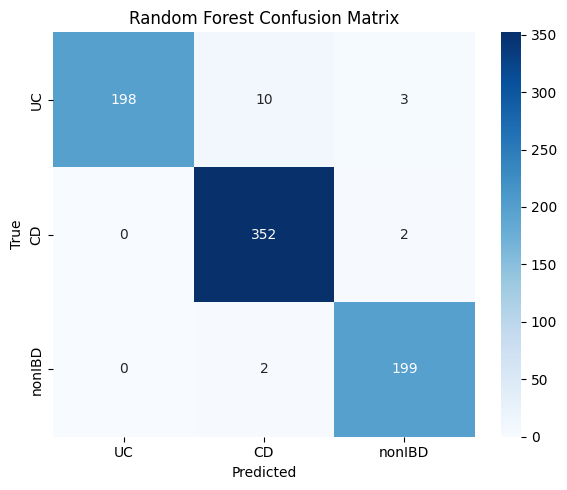

Top 20 important taxa:
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Rikenellaceae|g__Alistipes|s__Alistipes_putredinis                                                                               0.022352
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Odoribacteraceae|g__Odoribacter|s__Odoribacter_splanchnicus                                                                      0.019202
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_xylanisolvens                                                                       0.017818
k__Bacteria|p__Firmicutes|c__Firmicutes_unclassified|o__Firmicutes_unclassified|f__Firmicutes_unclassified|g__Firmicutes_unclassified|s__Firmicutes_bacterium_CAG_83                             0.014169
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_stercoris                                                   

In [ ]:
# =========================================================
# 4) FILTER TO DIAGNOSIS CLASSES
# =========================================================
data = merged[merged["diagnosis"].isin(["UC", "CD", "nonIBD"])].copy()
print("Filtered shape:", data.shape)
print(data["diagnosis"].value_counts())
print()

# =========================================================
# 5) PREPARE MODEL INPUT
# =========================================================
label_map = {"UC": 0, "CD": 1, "nonIBD": 2}
y = data["diagnosis"].map(label_map)

# species columns only from the MGX matrix
feature_cols = [c for c in X.columns if c != "sample_id"]

# use only microbiome features, not metadata columns
X_model = data[feature_cols].copy()

print("Model matrix shape:", X_model.shape)


# =========================================================
# 6) TRAIN/TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# 7) BASELINE MODELS
# =========================================================
lr_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        multi_class="multinomial"
    ))
])

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# =========================================================
# 8) EVALUATION
# =========================================================
def evaluate_model(name, y_true, y_pred):
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Macro F1:", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("Weighted F1:", round(f1_score(y_true, y_pred, average="weighted"), 4))
    print()
    print(classification_report(y_true, y_pred, target_names=["UC", "CD", "nonIBD"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

evaluate_model("LOGISTIC REGRESSION", y_test, lr_pred)
evaluate_model("RANDOM FOREST", y_test, rf_pred)

# =========================================================
# 9) PLOT CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["UC", "CD", "nonIBD"],
    yticklabels=["UC", "CD", "nonIBD"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# =========================================================
# 10) TOP FEATURES
# =========================================================
rf_clf = rf_model.named_steps["clf"]
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("Top 20 important taxa:")
print(importances.head(20).to_string())

### Next step:

- For imbalanced dataset, the best approach is to use stratified splitting + class_weight='balanced'; but can also try Random Forest which handles imbalance slightly better than logistic regression.

